# Taller 2 · De 16 canales a la figura valentina ojeda y valentina vasquez

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [ ]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 1.1 MB/s eta 0:00:00


Retrieving folder contents


Processing file 1H6kPtLbOGiWSREU4gGVLgKL2HYa6b-rK car1_amplitud.png
Processing file 1UnEgB-Yg9o0cv30BIgf3yHUNaB_yZiWx car2_anchura.png
Processing file 11Qisb4bJBZrj-kqV6ybi_pIQGHR0lQT_ car3_interpolar.png
Processing file 1o3EofLWhdsZnrPUw0inRb5E2lYw7gJS_ car4_centroide.png
Processing file 1KEB5CBNtovTU6O56UkuD3tc5tpfY3HfE car5_caida.png
Processing file 1qZ3_12WdDROAAY7N90YPK1bfqoJOx6nw car6_razon.png
Processing file 1WS82YFlZMwxWyCdZP0Tz-5SQqg8PK6Jr taller2_limpia.h5
Processing file 11PIHZsY2VvL7bk4xbYROu2cmqWkmT5U0 taller2_ruidosa.h5
Processing file 1EfK8kxbX9-t1N-MvUMSACB_aExVlgssa verificacion.py


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1H6kPtLbOGiWSREU4gGVLgKL2HYa6b-rK
To: /content/car1_amplitud.png
100%|██████████| 42.8k/42.8k [00:00<00:00, 31.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UnEgB-Yg9o0cv30BIgf3yHUNaB_yZiWx
To: /content/car2_anchura.png
100%|██████████| 52.2k/52.2k [00:00<00:00, 24.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=11Qisb4bJBZrj-kqV6ybi_pIQGHR0lQT_
To: /content/car3_interpolar.png
100%|██████████| 38.7k/38.7k [00:00<00:00, 27.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o3EofLWhdsZnrPUw0inRb5E2lYw7gJS_
To: /content/car4_centroide.png
100%|██████████| 48.0k/48.0k [00:00<00:00, 28.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KEB5CBNtovTU6O56UkuD3tc5tpfY3HfE
To: /content/car5_caida.png
100%|██████████| 54.3k/54.3k [00:00<00:00, 50.2MB/s]
Downloading...
From: https://drive.google.com/

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB



Download completed


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


In [ ]:
# ✏️ Ejercicio 1
#explorar:
def info_archivo(nombre_archivo):
    with h5py.File(nombre_archivo, "r") as f:
        fs = f.attrs["frecuencia_muestreo_hz"]
        escala = f.attrs["escala_uV_por_bit"]
        x = f["geometria/canal_x_um"][:]
        y = f["geometria/canal_y_um"][:]
        forma = f["registro/datos"].shape

    print("Frecuencia de muestreo:", fs, "Hz")
    print("Escala:", escala, "uV/bit")
    print("Forma del registro:", forma)
    print("x:", x)
    print("y:", y)

    return fs, escala, x, y

In [ ]:
fs, escala, x, y = info_archivo("taller2_limpia.h5")

Frecuencia de muestreo: 15000 Hz
Escala: 0.195 uV/bit
Forma del registro: (16, 1350000)
x: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
y: [  0.  40.  80. 120. 160. 200. 240. 280. 320. 360. 400. 440. 480. 520.
 560. 600.]


In [ ]:
#dibujar
def dibujar_sonda(x, y):
    plt.figure(figsize=(4, 8))

    plt.scatter(x, y, s=100)

    for canal in range(len(x)):
        plt.text(
            x[canal] + 8,
            y[canal],
            f"Canal {canal}",
            va="center",
            fontsize=9
        )

    plt.xlim(-50, 100)

    plt.xlabel("Posición x (µm)")
    plt.ylabel("Posición y (µm)")
    plt.title("Geometría de la sonda")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()



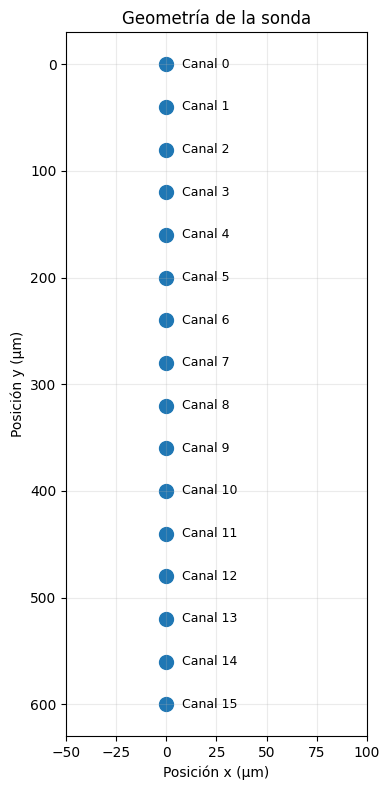

In [ ]:
dibujar_sonda(x, y)

In [ ]:
#grabacion
#c

def cargar_registro(nombre_archivo):
    with h5py.File(nombre_archivo, "r") as f:
        escala = f.attrs["escala_uV_por_bit"]
        fs = f.attrs["frecuencia_muestreo_hz"]

        datos = f["registro/datos"][:].astype(float)
        datos_uV = datos * escala

    return datos_uV, fs

In [ ]:
#conversion y cargar
datos_uV, fs = cargar_registro("taller2_limpia.h5")

print(datos_uV.shape)

(16, 1350000)


In [ ]:
#filtro
def filtrar_registro(datos, fs, f_baja=300, f_alta=5000, orden=4):

    sos = butter(
        orden,
        [f_baja, f_alta],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    datos_filtrados = sosfiltfilt(sos, datos, axis=1)

    return datos_filtrados

In [ ]:
datos_filtrados = filtrar_registro(datos_uV, fs)

In [ ]:
def graficar_ventana(datos_crudos, datos_filtrados, fs, y,
                     inicio_s=10, duracion_s=0.5):

    inicio = int(inicio_s * fs)
    fin = int((inicio_s + duracion_s) * fs)

    tiempo = np.arange(inicio, fin) / fs

    crudo = datos_crudos[:, inicio:fin]
    filtrado = datos_filtrados[:, inicio:fin]

    # Separación visual entre canales
    separacion_crudo = np.percentile(np.abs(crudo), 99) * 3
    separacion_filtrado = np.percentile(np.abs(filtrado), 99) * 3

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

    for canal in range(crudo.shape[0]):

        axes[0].plot(
            tiempo,
            crudo[canal] + canal * separacion_crudo,
            linewidth=0.7
        )

        axes[1].plot(
            tiempo,
            filtrado[canal] + canal * separacion_filtrado,
            linewidth=0.7
        )

    axes[0].set_title("Señal cruda")
    axes[1].set_title("Señal filtrada (300–5000 Hz)")

    axes[0].set_xlabel("Tiempo (s)")
    axes[1].set_xlabel("Tiempo (s)")

    axes[0].set_ylabel("Canal / profundidad")

    axes[0].set_yticks(
        np.arange(16) * separacion_crudo
    )
    axes[0].set_yticklabels(
        [f"Ch {i} ({int(y[i])} µm)" for i in range(16)]
    )

    axes[1].set_yticks(
        np.arange(16) * separacion_filtrado
    )
    axes[1].set_yticklabels(
        [f"Ch {i} ({int(y[i])} µm)" for i in range(16)]
    )

    plt.tight_layout()
    plt.show()

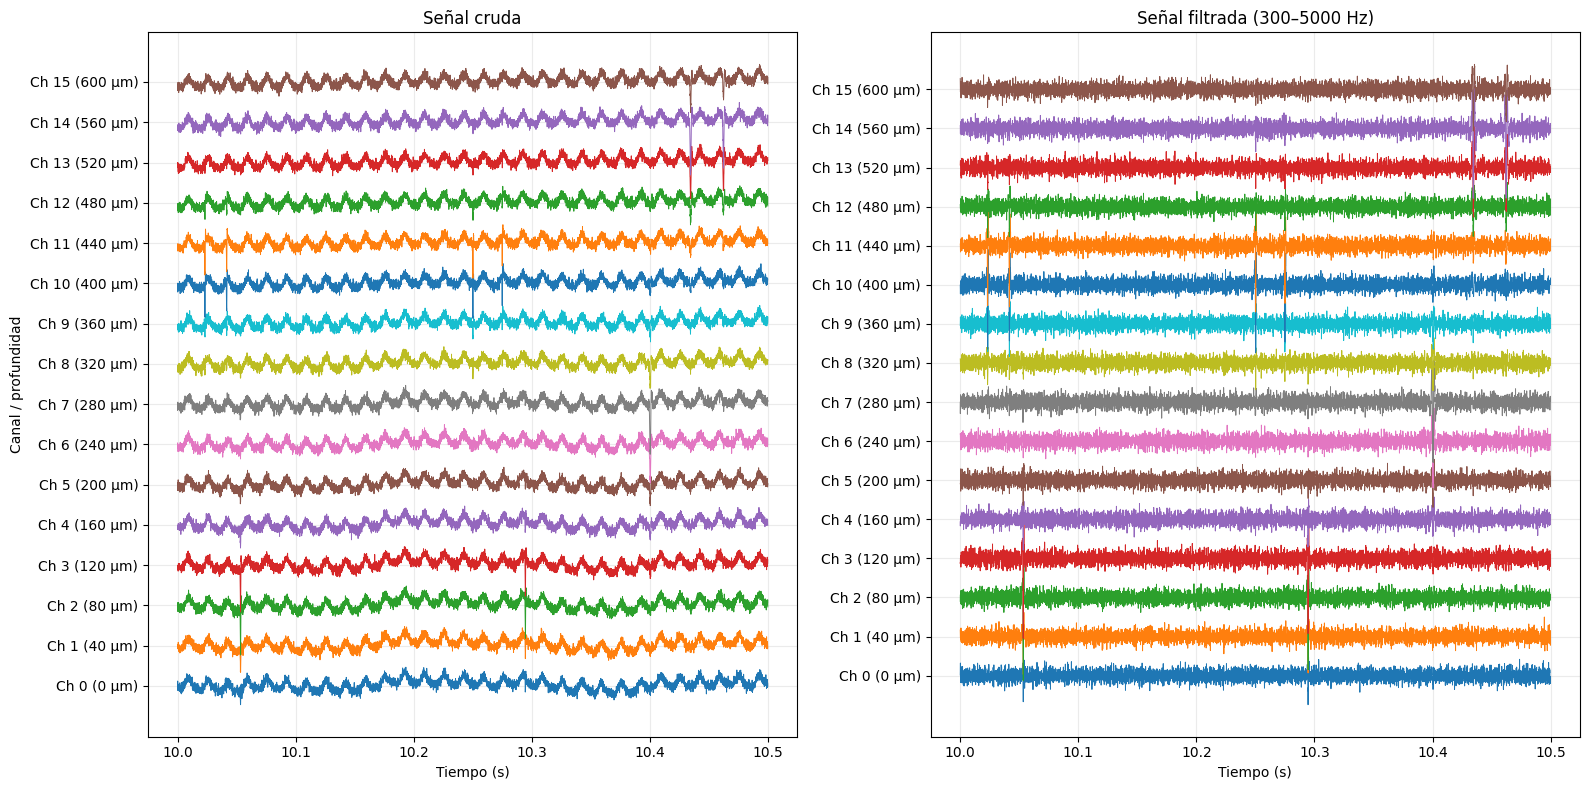

In [ ]:
graficar_ventana(
    datos_uV,
    datos_filtrados,
    fs,
    y,
    inicio_s=10,
    duracion_s=0.5
)

**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**ANS -->** b

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

Consideramos que no es una sola neurona, debido a que la amplitud de los potenciales de accion deberia estar disminuyendo con mas distancia del elctrodo (1/r). Por ende si el evento esta presente en todos los 16 canales, podria ser ruidio por parte de un electronic device.




---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**

In [ ]:
# ✍️ Ejercicio 2
def detectar(X, k=4.5, muerto_ms=0.5, fs=15000):
    # 1. Estimar el ruido y calcular un umbral diferente para cada canal
    ruido = np.median(np.abs(X), axis=1) / 0.6745
    umbrales = -k * ruido

    cruces = []

    # 2. Buscar los cruces negativos del umbral en cada canal
    for canal in range(X.shape[0]):
        indices = np.where(
            (X[canal, 1:] < umbrales[canal]) &
            (X[canal, :-1] >= umbrales[canal])
        )[0] + 1

        for indice in indices:
            cruces.append((indice, canal))

    # Si no se detectó nada, devolver arreglos vacíos
    if len(cruces) == 0:
        return np.array([]), np.array([], dtype=int)

    # Ordenar todos los cruces según el tiempo
    cruces.sort(key=lambda x: x[0])

    # Convertir la ventana de 0.5 ms a número de muestras
    muerto_muestras = int(round(muerto_ms / 1000 * fs))

    # 3. Juntar cruces cercanos que correspondan al mismo evento
    grupos = []
    grupo_actual = [cruces[0]]

    for cruce in cruces[1:]:
        if cruce[0] - grupo_actual[-1][0] <= muerto_muestras:
            grupo_actual.append(cruce)
        else:
            grupos.append(grupo_actual)
            grupo_actual = [cruce]

    grupos.append(grupo_actual)

    tiempos = []
    canales_pico = []

    # Buscar el punto más negativo de cada evento
    for grupo in grupos:
        inicio = grupo[0][0]
        fin = grupo[-1][0] + muerto_muestras

        # Evitar pasarnos del final de la grabación
        fin = min(fin, X.shape[1] - 1)

        # Canales que participaron en este evento
        canales = np.unique([canal for _, canal in grupo])

        segmento = X[canales, inicio:fin + 1]

        # Posición del valor más negativo
        fila, columna = np.unravel_index(
            np.argmin(segmento),
            segmento.shape
        )

        canal_pico = canales[fila]
        muestra_pico = inicio + columna

        tiempos.append(muestra_pico / fs)
        canales_pico.append(canal_pico)

    return np.array(tiempos), np.array(canales_pico)

In [ ]:
tiempos_eventos, canales_pico = detectar(datos_filtrados)

print("Número de eventos:", len(tiempos_eventos))
print("Primeros tiempos:", tiempos_eventos[:10])
print("Primeros canales pico:", canales_pico[:10])

Número de eventos: 2705
Primeros tiempos: [0.10366667 0.1058     0.11273333 0.24313333 0.27593333 0.28886667
 0.32486667 0.3522     0.3538     0.4144    ]
Primeros canales pico: [ 7  7 11 11 11 11 11  3 10 14]


In [ ]:

tiempos_02, canales_02 = detectar(
    datos_filtrados,
    k=4.5,
    muerto_ms=0.2,
    fs=15000
)

print("Número de eventos con 0.2 ms:", len(tiempos_02))

Número de eventos con 0.2 ms: 2965


In [ ]:
tiempos_05, canales_05 = detectar(
    datos_filtrados,
    k=4.5,
    muerto_ms=0.5,
    fs=15000
)

print("Eventos con 0.5 ms:", len(tiempos_05))
print("Eventos con 0.2 ms:", len(tiempos_02))
print("Eventos adicionales:", len(tiempos_02) - len(tiempos_05))

Eventos con 0.5 ms: 2705
Eventos con 0.2 ms: 2965
Eventos adicionales: 260


**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

**ANS-->** b

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

En el periodo muesrto de 0.5 ms se detectaron 2786 eventos, en comparacion con los 4827 eventos de 0.2 ms, una diferencia de 2041 eventos. Si se usara 5ms se podrian fusionar disparos de neuronas dierentes y por ende hacer que los datos sean mas "muddy" y se peirdan eventos.



---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

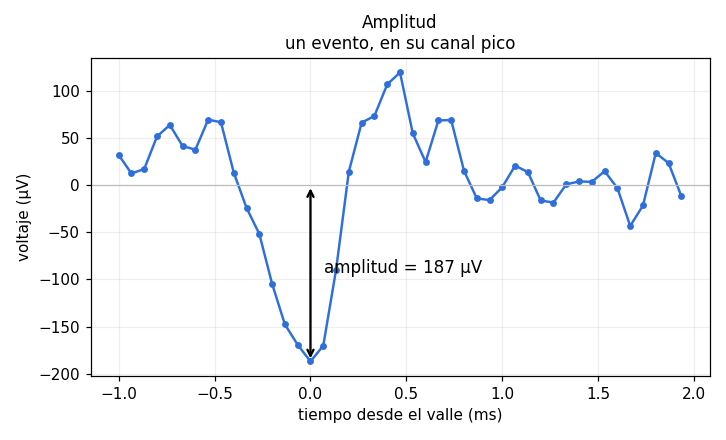

In [ ]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

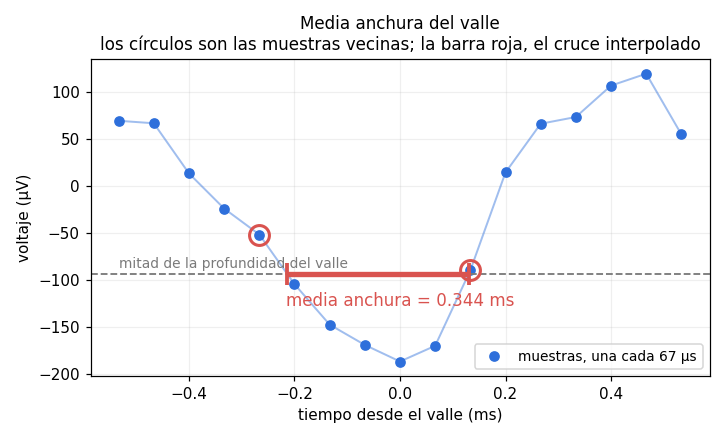

In [ ]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

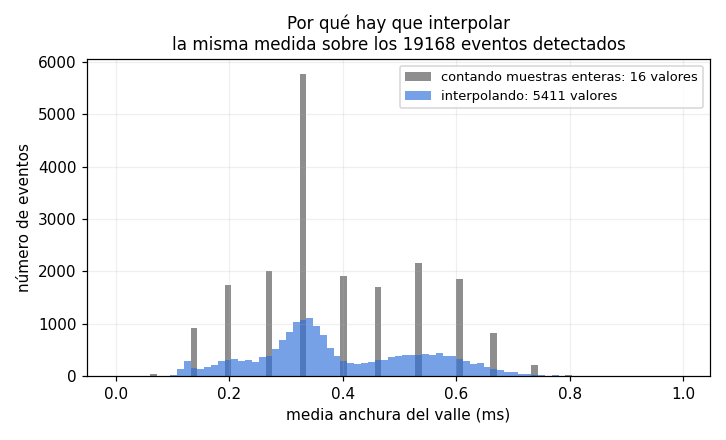

In [ ]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

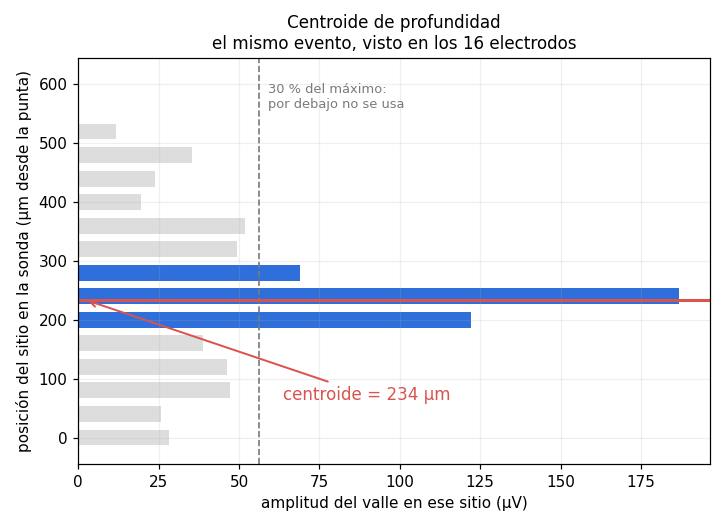

In [ ]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

In [ ]:
tiempos_eventos, canales_pico = detectar(
    datos_filtrados,
    k=4.5,
    muerto_ms=0.5,
    fs=15000
)

print("Eventos detectados:", len(tiempos_eventos))

Eventos detectados: 2705


In [ ]:
# ✏️ Ejercicio 3
# Ejercicio 3a: Extraer formas de onda

def extraer_formas(X, tiempos, canales_pico, fs=15000,
                   antes_ms=1.0, despues_ms=2.0):

    antes = int(round(antes_ms / 1000 * fs))
    despues = int(round(despues_ms / 1000 * fs))

    formas = []
    tiempos_validos = []
    canales_validos = []

    for tiempo, canal in zip(tiempos, canales_pico):

        centro = int(round(tiempo * fs))

        inicio = centro - antes
        fin = centro + despues + 1

        # Evitar eventos demasiado cerca del inicio o final
        if inicio >= 0 and fin <= X.shape[1]:
            formas.append(X[:, inicio:fin])
            tiempos_validos.append(tiempo)
            canales_validos.append(canal)

    return (
        np.array(formas),
        np.array(tiempos_validos),
        np.array(canales_validos)
    )

In [ ]:
formas, tiempos_validos, canales_validos = extraer_formas(
    datos_filtrados,
    tiempos_eventos,
    canales_pico,
    fs=15000
)

print("Forma del arreglo:", formas.shape)

Forma del arreglo: (2705, 16, 46)


In [ ]:
# Ejercicio 3b: Calcular características

def media_anchura(waveform, fs=15000):
    # Encontrar el valle
    i_pico = np.argmin(waveform)
    valle = waveform[i_pico]

    # Mitad de la profundidad del valle
    mitad = valle / 2

    # Buscar cruce a la izquierda
    izquierda = None

    for i in range(i_pico - 1, -1, -1):
        if waveform[i] >= mitad and waveform[i + 1] < mitad:

            y1 = waveform[i]
            y2 = waveform[i + 1]

            izquierda = i + (mitad - y1) / (y2 - y1)
            break

    # Buscar cruce a la derecha
    derecha = None

    for i in range(i_pico, len(waveform) - 1):
        if waveform[i] < mitad and waveform[i + 1] >= mitad:

            y1 = waveform[i]
            y2 = waveform[i + 1]

            derecha = i + (mitad - y1) / (y2 - y1)
            break

    # Si no encontramos ambos cruces
    if izquierda is None or derecha is None:
        return np.nan

    anchura_muestras = derecha - izquierda

    return anchura_muestras / fs * 1000

In [ ]:
def calcular_caracteristicas(formas, canales_pico, y, fs=15000):

    n_eventos = formas.shape[0]

    amplitudes = np.zeros(n_eventos)
    anchuras = np.zeros(n_eventos)
    centroides = np.zeros(n_eventos)

    for i in range(n_eventos):

        forma = formas[i]
        canal = canales_pico[i]


        # 1. AMPLITUD

        onda_pico = forma[canal]

        valle = np.min(onda_pico)

        # La expresamos como magnitud positiva en µV
        amplitudes[i] = -valle


        # 2. MEDIA ANCHURA DEL VALLE

        anchuras[i] = media_anchura(
            onda_pico,
            fs=fs
        )


        # 3. CENTROIDE


        # Amplitud del valle en cada uno de los 16 canales
        perfil = -np.min(forma, axis=1)

        # Evitar amplitudes negativas por alguna situación extraña
        perfil = np.maximum(perfil, 0)

        maximo = np.max(perfil)

        # Solo canales con al menos 30 % del máximo
        usar = perfil >= 0.30 * maximo

        centroides[i] = np.sum(
            y[usar] * perfil[usar]
        ) / np.sum(perfil[usar])

    return amplitudes, anchuras, centroides

In [ ]:
amplitudes, anchuras, centroides = calcular_caracteristicas(
    formas,
    canales_validos,
    y,
    fs=15000
)

In [ ]:
print("Amplitudes:", amplitudes.shape)
print("Anchuras:", anchuras.shape)
print("Centroides:", centroides.shape)

print("\nPrimeras amplitudes:", amplitudes[:5])
print("Primeras anchuras:", anchuras[:5])
print("Primeros centroides:", centroides[:5])

Amplitudes: (2705,)
Anchuras: (2705,)
Centroides: (2705,)

Primeras amplitudes: [177.56883352  57.45620711 167.2579024  162.0094343  176.58888377]
Primeras anchuras: [0.60917733 0.21621812 0.29193295 0.37305181 0.32884806]
Primeros centroides: [273.70378916 287.53688347 436.12943126 409.16781337 418.27761397]


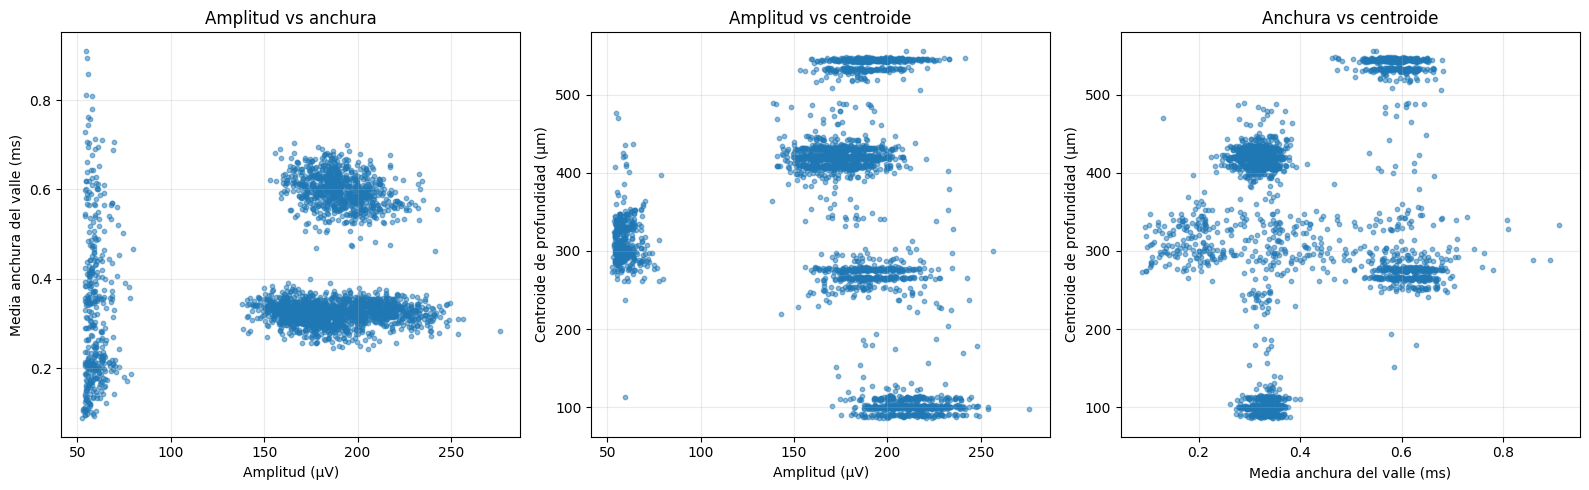

In [ ]:
# Ejercicio 3c: Tres nubes de puntos

validos = (
    np.isfinite(amplitudes) &
    np.isfinite(anchuras) &
    np.isfinite(centroides)
)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Amplitud vs anchura
axes[0].scatter(
    amplitudes[validos],
    anchuras[validos],
    s=10,
    alpha=0.5
)

axes[0].set_xlabel("Amplitud (µV)")
axes[0].set_ylabel("Media anchura del valle (ms)")
axes[0].set_title("Amplitud vs anchura")


# Amplitud vs centroide
axes[1].scatter(
    amplitudes[validos],
    centroides[validos],
    s=10,
    alpha=0.5
)

axes[1].set_xlabel("Amplitud (µV)")
axes[1].set_ylabel("Centroide de profundidad (µm)")
axes[1].set_title("Amplitud vs centroide")


# Anchura vs centroide
axes[2].scatter(
    anchuras[validos],
    centroides[validos],
    s=10,
    alpha=0.5
)

axes[2].set_xlabel("Media anchura del valle (ms)")
axes[2].set_ylabel("Centroide de profundidad (µm)")
axes[2].set_title("Anchura vs centroide")


plt.tight_layout()
plt.show()


**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario

**ANS -->** d

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

*Su respuesta:*

El primer panel, de centroide vs media anchura, demuestra una mejor distincion entre los grupos, ya que usa la profundidad estimada de la neurona y la duración de sus potenciales de acción.



---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


In [ ]:
# ✏️ Ejercicio 4

# Ejercicio 4a: Grabación ruidosa

import gc

for nombre in ["datos_uV", "datos_filtrados", "formas"]:
    if nombre in globals():
        del globals()[nombre]

gc.collect()

92

In [ ]:
datos_uV, fs = cargar_registro("taller2_ruidosa.h5")

datos_filtrados = filtrar_registro(datos_uV, fs)

tiempos_eventos, canales_pico = detectar(
    datos_filtrados,
    k=4.5,
    muerto_ms=0.5,
    fs=fs
)

print("Eventos detectados:", len(tiempos_eventos))

Eventos detectados: 18639


In [ ]:
formas, tiempos_validos, canales_validos = extraer_formas(
    datos_filtrados,
    tiempos_eventos,
    canales_pico,
    fs=fs
)

In [ ]:
with h5py.File("taller2_ruidosa.h5", "r") as f:
    y = f["geometria/canal_y_um"][:]

In [ ]:
amplitudes, anchuras, centroides = calcular_caracteristicas(
    formas,
    canales_validos,
    y,
    fs=fs
)

In [ ]:
validos = (
    np.isfinite(amplitudes) &
    np.isfinite(anchuras) &
    np.isfinite(centroides)
)

amp = amplitudes[validos]
anch = anchuras[validos]
cent = centroides[validos]

print("Eventos con características válidas:", len(amp))

Eventos con características válidas: 18556


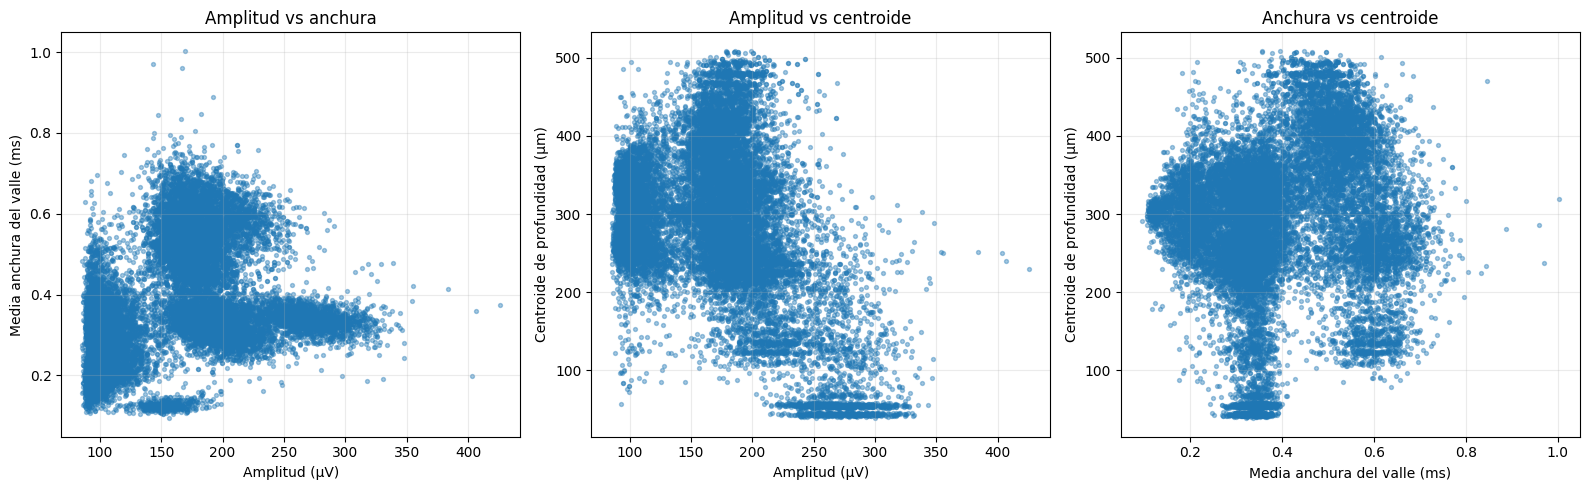

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(amp, anch, s=8, alpha=0.4)
axes[0].set_xlabel("Amplitud (µV)")
axes[0].set_ylabel("Media anchura del valle (ms)")
axes[0].set_title("Amplitud vs anchura")

axes[1].scatter(amp, cent, s=8, alpha=0.4)
axes[1].set_xlabel("Amplitud (µV)")
axes[1].set_ylabel("Centroide de profundidad (µm)")
axes[1].set_title("Amplitud vs centroide")

axes[2].scatter(anch, cent, s=8, alpha=0.4)
axes[2].set_xlabel("Media anchura del valle (ms)")
axes[2].set_ylabel("Centroide de profundidad (µm)")
axes[2].set_title("Anchura vs centroide")

plt.tight_layout()
plt.show()

In [ ]:

# Ejercicio 4b: Estandarización

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

caracteristicas = np.column_stack([
    amp,
    anch,
    cent
])

print(caracteristicas.shape)

scaler = StandardScaler()
caracteristicas_z = scaler.fit_transform(caracteristicas)

print("Medias:", caracteristicas_z.mean(axis=0))
print("Desviaciones:", caracteristicas_z.std(axis=0))

(18556, 3)
Medias: [-4.11869049e-15 -5.29148472e-15  8.48583048e-15]
Desviaciones: [1. 1. 1.]


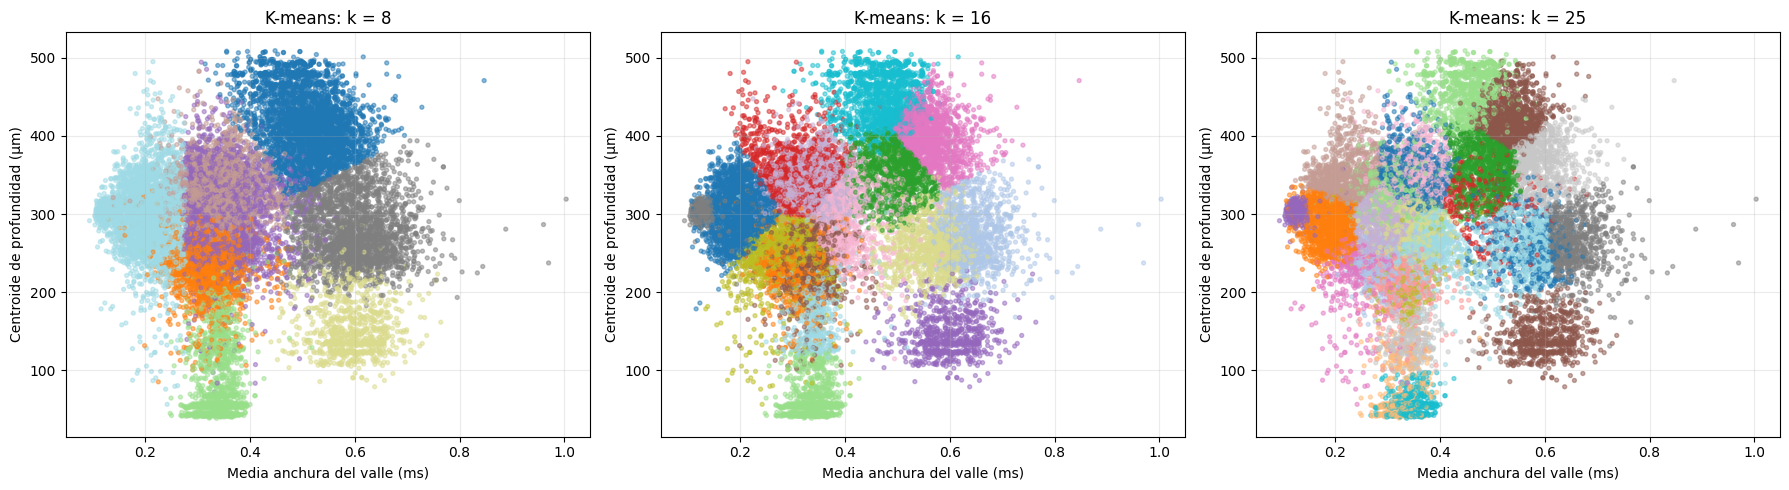

In [ ]:
#ejercio 4c: comparar tres valores de k

valores_k = [8, 16, 25]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, valores_k):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    grupos = modelo.fit_predict(caracteristicas_z)

    ax.scatter(
        anch,
        cent,
        c=grupos,
        s=8,
        alpha=0.5,
        cmap="tab20"
    )

    ax.set_xlabel("Media anchura del valle (ms)")
    ax.set_ylabel("Centroide de profundidad (µm)")
    ax.set_title(f"K-means: k = {k}")

plt.tight_layout()
plt.show()

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**ANS -->** d

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*

Seleccionamos K=16 y que no tiene tanta fusion de poblaciones y tampoco divide poblaciones continuas a unas mas pequeñas.



---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

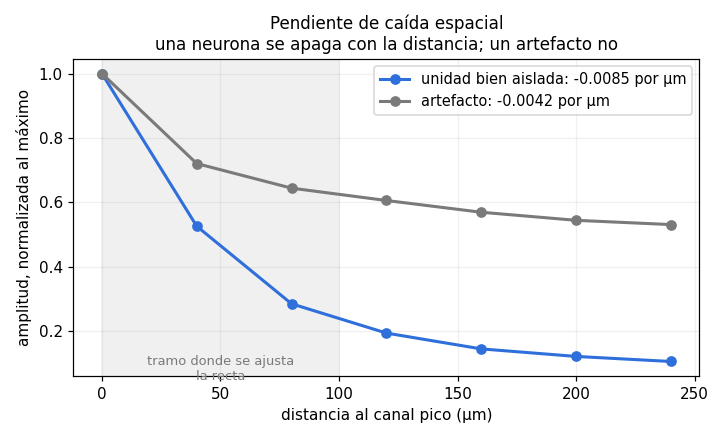

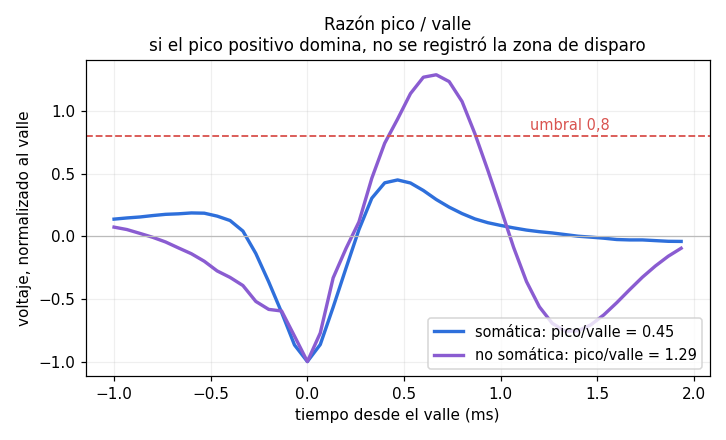

In [ ]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:** Necesito código en Python para calcular las 7 métricas de calidad de cada grupo que obtuve con K-means. Tengo las formas de onda de cada evento en los 16 canales, los tiempos, el canal pico de cada evento, sus amplitudes y la posición de los electrodos. Para cada grupo necesito: número de picos y valles de la forma de onda promedio, duración desde el valle hasta el pico de repolarización en µs, pendiente de caída espacial, razón pico/valle, porcentaje de violaciones del refractario usando intervalos menores de 2 ms, porcentaje estimado de disparos faltantes y número de disparos. Para la caída espacial no promedies directamente los 16 canales porque los eventos pueden tener canales pico distintos: normaliza el perfil de cada evento por su máximo, calcula la distancia respecto al canal pico de ese evento, junta los datos y ajusta una recta solo hasta 100 µm. Para los disparos faltantes ajusta una gaussiana usando solo la parte del histograma que está por encima del pico y calcula qué fracción queda por debajo del umbral de detección. Si ese ajuste falla deja ese valor como NaN. Al final arma una tabla de pandas con una fila por grupo. Trata de hacerlo en funciones y con comentarios para poder entender qué hace cada parte.

In [ ]:
# ✍️ Ejercicio 5
# Ejercicio 5: Preparar los datos

k_elegido = 16  # cambiar si elegimos otro

modelo_final = KMeans(
    n_clusters=k_elegido,
    random_state=42,
    n_init=10
)

grupos_final = modelo_final.fit_predict(caracteristicas_z)

print("Número de grupos:", len(np.unique(grupos_final)))

Número de grupos: 16


In [ ]:
formas_v = formas[validos]
tiempos_v = tiempos_validos[validos]
canales_v = canales_validos[validos]
amplitudes_v = amplitudes[validos]

print(formas_v.shape)
print(tiempos_v.shape)
print(canales_v.shape)
print(amplitudes_v.shape)
print(grupos_final.shape)

(18556, 16, 46)
(18556,)
(18556,)
(18556,)
(18556,)


In [ ]:
import pandas as pd

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import norm

In [ ]:
def estimar_faltantes(amplitudes_grupo, umbral):
    # Histograma de amplitudes
    conteos, bordes = np.histogram(amplitudes_grupo, bins="auto")
    centros = (bordes[:-1] + bordes[1:]) / 2

    # El pico del histograma se usa como centro de la campana
    i_pico = np.argmax(conteos)
    mu = centros[i_pico]

    # Usar solamente la mitad derecha del histograma
    usar = (centros >= mu) & (conteos > 0)

    x = centros[usar]
    y_hist = conteos[usar]

    if len(x) < 3:
        return np.nan

    # Gaussiana con el centro fijado en el pico del histograma
    def gaussiana(x, A, sigma):
        return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    try:
        sigma_inicial = np.std(amplitudes_grupo)

        parametros, _ = curve_fit(
            gaussiana,
            x,
            y_hist,
            p0=[np.max(y_hist), sigma_inicial],
            bounds=(
                [0, 1e-6],
                [np.inf, np.inf]
            ),
            maxfev=10000
        )

        A, sigma = parametros

        # Fracción estimada de la campana que quedó debajo del umbral
        fraccion_faltante = norm.cdf(
            umbral,
            loc=mu,
            scale=sigma
        )

        return fraccion_faltante

    except:
        return np.nan

In [ ]:
def calcular_metricas_grupos(
    formas,
    tiempos,
    canales_pico,
    amplitudes,
    grupos,
    y_sonda,
    X_filtrada,
    fs=15000,
    k_det=4.5
):

    filas = []

    # Ruido y magnitud del umbral para cada canal
    ruido = np.median(np.abs(X_filtrada), axis=1) / 0.6745
    umbral_por_canal = k_det * ruido

    for grupo in np.unique(grupos):

        # Eventos que pertenecen a este grupo
        idx = np.where(grupos == grupo)[0]

        formas_g = formas[idx]
        tiempos_g = tiempos[idx]
        canales_g = canales_pico[idx]
        amplitudes_g = amplitudes[idx]

        n_disparos = len(idx)

        # --------------------------------
        # Forma de onda promedio
        # --------------------------------
        # De cada evento usamos su propio canal pico
        # Forma de onda promedio del grupo en los 16 canales
        forma_promedio_16 = np.mean(formas_g, axis=0)

        # Buscar en qué canal la forma promedio tiene el valle más profundo
        canal_promedio = np.argmin(
            np.min(forma_promedio_16, axis=1)
        )

        # Usar ese canal para las métricas de forma de onda
        onda_promedio = forma_promedio_16[canal_promedio]

        # Valle principal
        i_valle = np.argmin(onda_promedio)
        valle = onda_promedio[i_valle]

        # --------------------------------
        # 1. Número de picos y valles
        # --------------------------------
        # Una prominencia pequeña evita contar ruido diminuto
        prominencia = 0.1 * abs(valle)

        picos, _ = find_peaks(
            onda_promedio,
            prominence=prominencia
        )

        valles, _ = find_peaks(
            -onda_promedio,
            prominence=prominencia
        )

        n_picos = len(picos)
        n_valles = len(valles)

        # --------------------------------
        # 2. Duración valle -> repolarización
        # --------------------------------
        despues_valle = onda_promedio[i_valle + 1:]

        if len(despues_valle) > 0:
            i_pico_post = (
                i_valle + 1 + np.argmax(despues_valle)
            )

            duracion_us = (
                (i_pico_post - i_valle) / fs * 1e6
            )
        else:
            duracion_us = np.nan

        # --------------------------------
        # 3. Pendiente de caída espacial
        # --------------------------------
        distancias = []
        amplitudes_norm = []

        for i in range(n_disparos):

            # Valle de este evento en cada electrodo
            # Instante del valle del evento en su canal pico
            i_valle_evento = np.argmin(
                formas_g[i, canales_g[i], :]
            )

            # Amplitud en los 16 canales en ESE MISMO instante
            perfil = -formas_g[i, :, i_valle_evento]

            # Nos quedamos con magnitudes positivas
            perfil = np.maximum(perfil, 0)

            maximo = np.max(perfil)

            if maximo == 0:
                continue

            perfil_norm = perfil / maximo

            # Distancia respecto al canal pico DE ESTE evento
            canal = canales_g[i]
            distancia = np.abs(
                y_sonda - y_sonda[canal]
            )

            # Solo hasta 100 µm
            usar = distancia <= 100

            distancias.extend(distancia[usar])
            amplitudes_norm.extend(perfil_norm[usar])

        distancias = np.array(distancias)
        amplitudes_norm = np.array(amplitudes_norm)

        if len(distancias) >= 2:
            pendiente = np.polyfit(
                distancias,
                amplitudes_norm,
                1
            )[0]
        else:
            pendiente = np.nan

        # --------------------------------
        # 4. Razón pico / valle

      # 4. Razón pico / valle
        pico_positivo = np.max(onda_promedio)

        if valle != 0:
            razon_pico_valle = pico_positivo / abs(valle)
        else:
            razon_pico_valle = np.nan

        # --------------------------------
        # 5. Violaciones del refractario
        # --------------------------------
        tiempos_ordenados = np.sort(tiempos_g)
        isi = np.diff(tiempos_ordenados)

        if len(isi) > 0:
            violaciones = np.mean(isi < 0.002)
        else:
            violaciones = np.nan

        # --------------------------------
        # 6. Disparos faltantes
        # --------------------------------
        # Cada evento puede tener un canal pico distinto,
        # así que usamos el umbral típico de sus canales pico.
        umbrales_g = umbral_por_canal[canales_g]
        umbral_grupo = np.median(umbrales_g)

        faltantes = estimar_faltantes(
            amplitudes_g,
            umbral_grupo
        )

        # --------------------------------
        # Guardar resultados
        # --------------------------------
        filas.append({
            "grupo": grupo,
            "n_disparos": n_disparos,
            "n_picos": n_picos,
            "n_valles": n_valles,
            "duracion_us": duracion_us,
            "pendiente_espacial": pendiente,
            "razon_pico_valle": razon_pico_valle,
            "violaciones_refractario_pct": violaciones * 100,
            "disparos_faltantes_pct": faltantes * 100
        })

    return pd.DataFrame(filas)

In [ ]:
tabla_metricas = calcular_metricas_grupos(
    formas_v,
    tiempos_v,
    canales_v,
    amplitudes_v,
    grupos_final,
    y,
    datos_filtrados,
    fs=fs,
    k_det=4.5
)

tabla_metricas

,grupo,n_disparos,n_picos,n_valles,duracion_us,pendiente_espacial,razon_pico_valle,violaciones_refractario_pct,disparos_faltantes_pct
0,0,1758,1,1,600.000000,-0.006295,0.429998,0.796813,4.481757e+01
1,1,1009,1,1,933.333333,-0.008212,0.643642,0.694444,1.707825e-04
2,2,1115,1,1,466.666667,-0.008447,0.443318,0.897666,1.674903e-08
3,3,1035,1,1,800.000000,-0.008504,0.590562,9.477756,1.329697e-03
4,4,1319,1,1,466.666667,-0.008957,0.485026,0.151745,2.498645e-09
5,5,1483,1,1,533.333333,-0.006934,0.413335,1.282051,3.686489e+01
6,6,734,1,1,933.333333,-0.008657,0.626878,0.409277,1.564618e-09
7,7,1700,1,1,533.333333,-0.008364,0.493330,2.413184,4.985712e-09
8,8,1261,1,1,466.666667,-0.008506,0.478967,0.873016,7.903915e-16
9,9,1361,1,1,800.000000,-0.008199,0.609232,8.529412,2.361657e-05


**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia
- **d)** una unidad no somática

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

**ANS -->** c

*Su respuesta:*  los grupos 0, 2, 5, 10, 12 y 15 tienen mas del 20% estimado de disparos faltantes por la uqe la distribucion de amplitudes esta cortada por el umbral. Al compara el grupo 0 con el grupo 4, en el primero falta parte de la zona de amplitudes bajas,  mientras que en el grupo de buena calidad. i.e. grupo 4, la distribucion esta mas completa. esto significa que en el grupo cortado varios disparos reales no fueron detectados.


---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

In [ ]:
# ✏️ Ejercicio 6
#a
def razon_refractaria(conteos, centros):
    # Banda que realmente nos interesa del refractario:
    # 0.5 a 2 ms, porque <0.5 ms ya lo eliminó el detector
    banda_refractaria = (
        (np.abs(centros) >= 0.5) &
        (np.abs(centros) < 2.0)
    )

    # Zona de referencia
    banda_referencia = (
        (np.abs(centros) >= 5.0) &
        (np.abs(centros) <= 20.0)
    )

    media_ref = np.mean(conteos[banda_referencia])

    if media_ref == 0:
        return np.nan

    return np.mean(conteos[banda_refractaria]) / media_ref

In [ ]:
def correlograma_cruzado(tiempos_a, tiempos_b,
                         max_ms=20, bin_ms=0.25):

    tiempos_a = np.sort(np.asarray(tiempos_a))
    tiempos_b = np.sort(np.asarray(tiempos_b))

    max_s = max_ms / 1000
    diferencias = []

    for t in tiempos_a:
        inicio = np.searchsorted(
            tiempos_b,
            t - max_s,
            side="left"
        )

        fin = np.searchsorted(
            tiempos_b,
            t + max_s,
            side="right"
        )

        dt = tiempos_b[inicio:fin] - t
        diferencias.extend(dt * 1000)

    bins = np.arange(
        -max_ms,
        max_ms + bin_ms,
        bin_ms
    )

    conteos, bordes = np.histogram(diferencias, bins=bins)
    centros = (bordes[:-1] + bordes[1:]) / 2

    razon = razon_refractaria(conteos, centros)

    return centros, conteos, razon

In [ ]:
def autocorrelograma(tiempos, max_ms=20, bin_ms=0.25):
    tiempos = np.sort(np.asarray(tiempos))

    max_s = max_ms / 1000
    diferencias = []

    # Comparar cada disparo con los siguientes
    # dentro de una ventana de 20 ms
    for i in range(len(tiempos)):
        fin = np.searchsorted(
            tiempos,
            tiempos[i] + max_s,
            side="right"
        )

        dt = tiempos[i + 1:fin] - tiempos[i]

        # Agregamos valores positivos y negativos
        # para que el autocorrelograma quede simétrico
        diferencias.extend(dt * 1000)
        diferencias.extend(-dt * 1000)

    bins = np.arange(
        -max_ms,
        max_ms + bin_ms,
        bin_ms
    )

    conteos, bordes = np.histogram(
        diferencias,
        bins=bins
    )

    centros = (bordes[:-1] + bordes[1:]) / 2

    razon = razon_refractaria(
        conteos,
        centros
    )

    return centros, conteos, razon

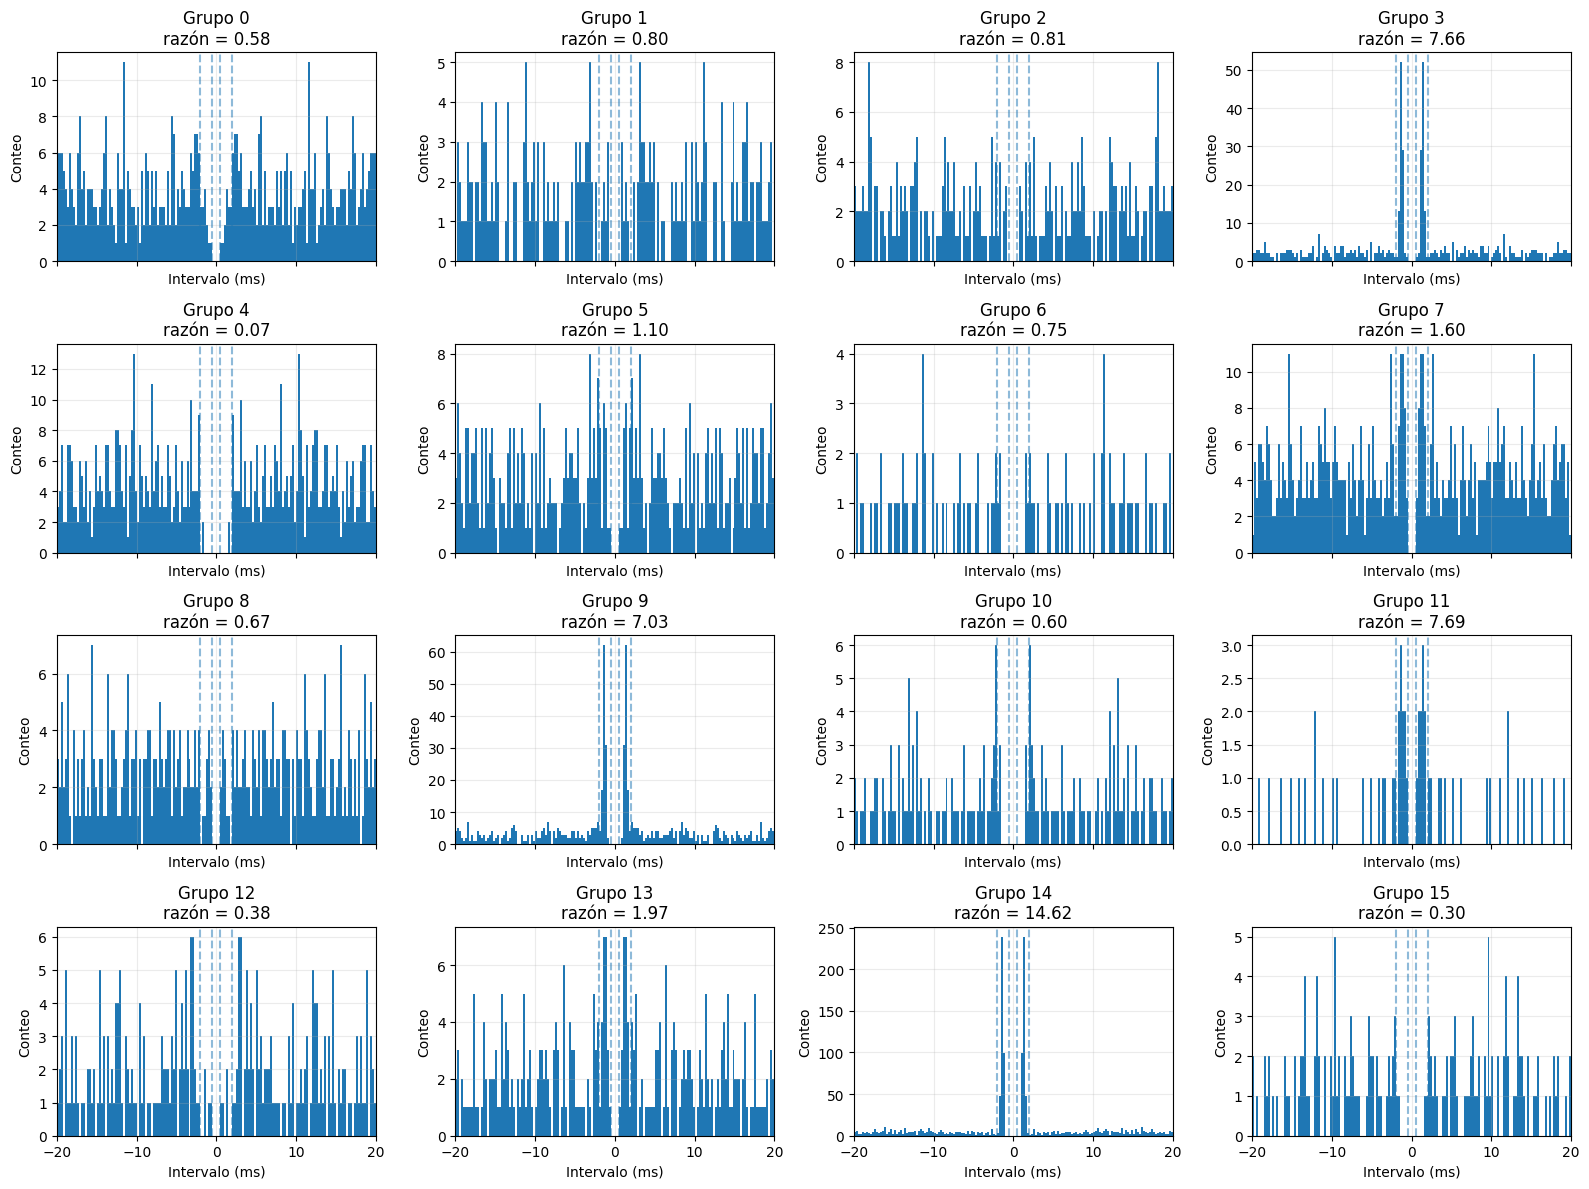

In [ ]:
#b
grupos_unicos = np.unique(grupos_final)

fig, axes = plt.subplots(
    4, 4,
    figsize=(16, 12),
    sharex=True
)

axes = axes.flatten()

for ax, grupo in zip(axes, grupos_unicos):

    tiempos_g = tiempos_v[grupos_final == grupo]

    centros, conteos, razon = autocorrelograma(
        tiempos_g
    )

    ax.bar(
        centros,
        conteos,
        width=0.25
    )

    ax.axvline(-2, linestyle="--", alpha=0.5)
    ax.axvline(-0.5, linestyle="--", alpha=0.5)
    ax.axvline(0.5, linestyle="--", alpha=0.5)
    ax.axvline(2, linestyle="--", alpha=0.5)

    ax.set_title(
        f"Grupo {grupo}\nrazón = {razon:.2f}"
    )

    ax.set_xlim(-20, 20)

for ax in axes:
    ax.set_xlabel("Intervalo (ms)")
    ax.set_ylabel("Conteo")

plt.tight_layout()
plt.show()

In [ ]:
centros_kmeans = modelo_final.cluster_centers_

parejas = []

for i in range(len(centros_kmeans)):
    for j in range(i + 1, len(centros_kmeans)):

        distancia = np.linalg.norm(
            centros_kmeans[i] - centros_kmeans[j]
        )

        parejas.append((i, j, distancia))

parejas = sorted(parejas, key=lambda x: x[2])

print("Parejas más cercanas:")
for a, b, distancia in parejas[:10]:
    print(f"Grupos {a} y {b}: distancia = {distancia:.3f}")

Parejas más cercanas:
Grupos 2 y 8: distancia = 0.703
Grupos 3 y 9: distancia = 0.735
Grupos 1 y 13: distancia = 0.780
Grupos 9 y 14: distancia = 0.904
Grupos 0 y 12: distancia = 0.914
Grupos 0 y 5: distancia = 0.942
Grupos 5 y 10: distancia = 0.981
Grupos 7 y 8: distancia = 1.022
Grupos 10 y 12: distancia = 1.028
Grupos 3 y 14: distancia = 1.032


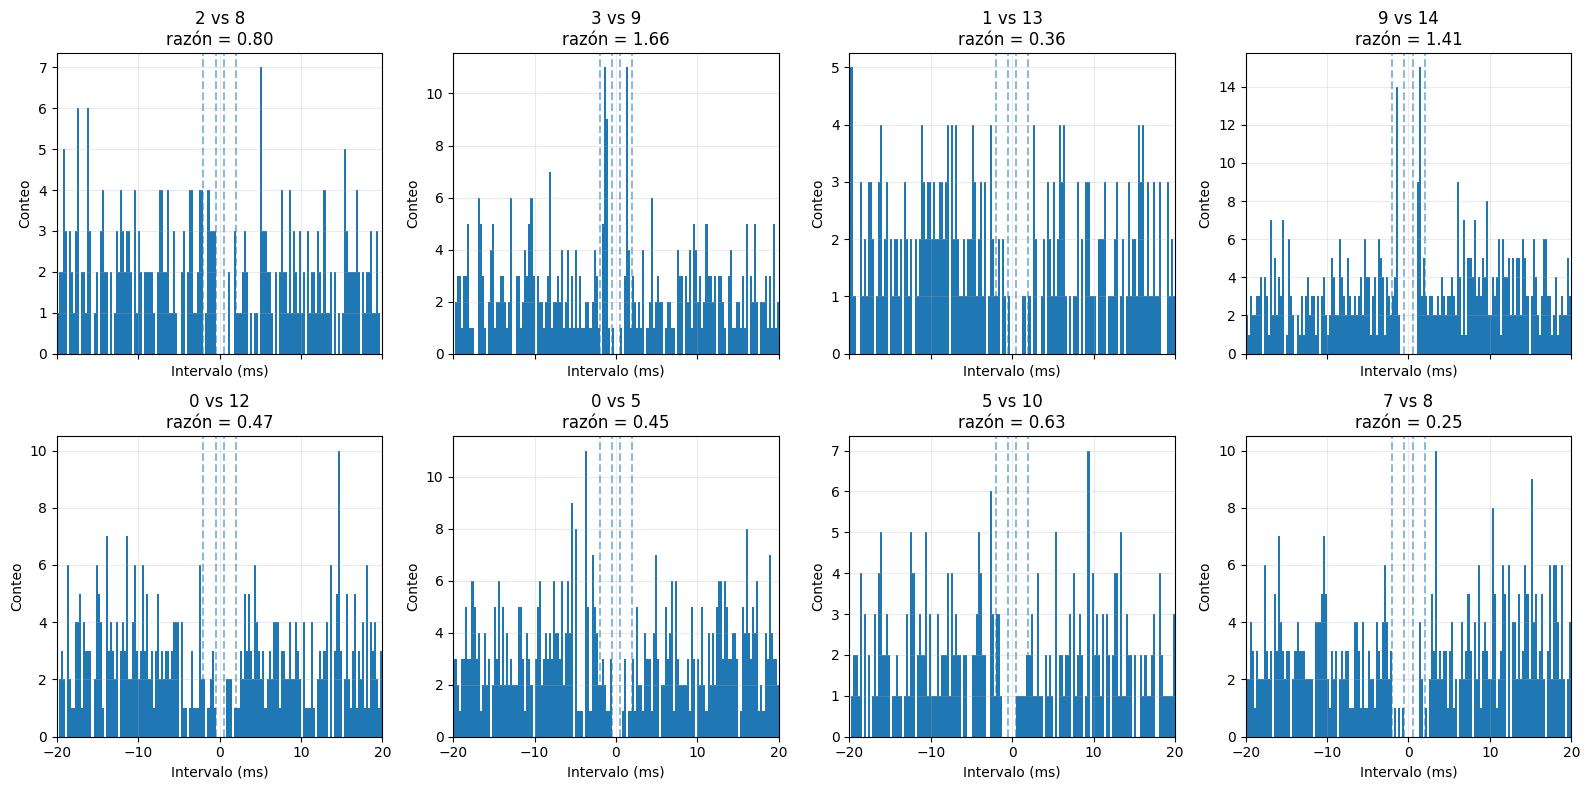

In [ ]:
parejas_candidatas = [
    (a, b)
    for a, b, distancia in parejas[:8]
]

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8),
    sharex=True
)

axes = axes.flatten()

for ax, (grupo_a, grupo_b) in zip(axes, parejas_candidatas):

    tiempos_a = tiempos_v[
        grupos_final == grupo_a
    ]

    tiempos_b = tiempos_v[
        grupos_final == grupo_b
    ]

    centros, conteos, razon = correlograma_cruzado(
        tiempos_a,
        tiempos_b
    )

    ax.bar(
        centros,
        conteos,
        width=0.25
    )

    ax.axvline(-2, linestyle="--", alpha=0.5)
    ax.axvline(-0.5, linestyle="--", alpha=0.5)
    ax.axvline(0.5, linestyle="--", alpha=0.5)
    ax.axvline(2, linestyle="--", alpha=0.5)

    ax.set_xlim(-20, 20)

    ax.set_title(
        f"{grupo_a} vs {grupo_b}\n"
        f"razón = {razon:.2f}"
    )

    ax.set_xlabel("Intervalo (ms)")
    ax.set_ylabel("Conteo")

plt.tight_layout()
plt.show()

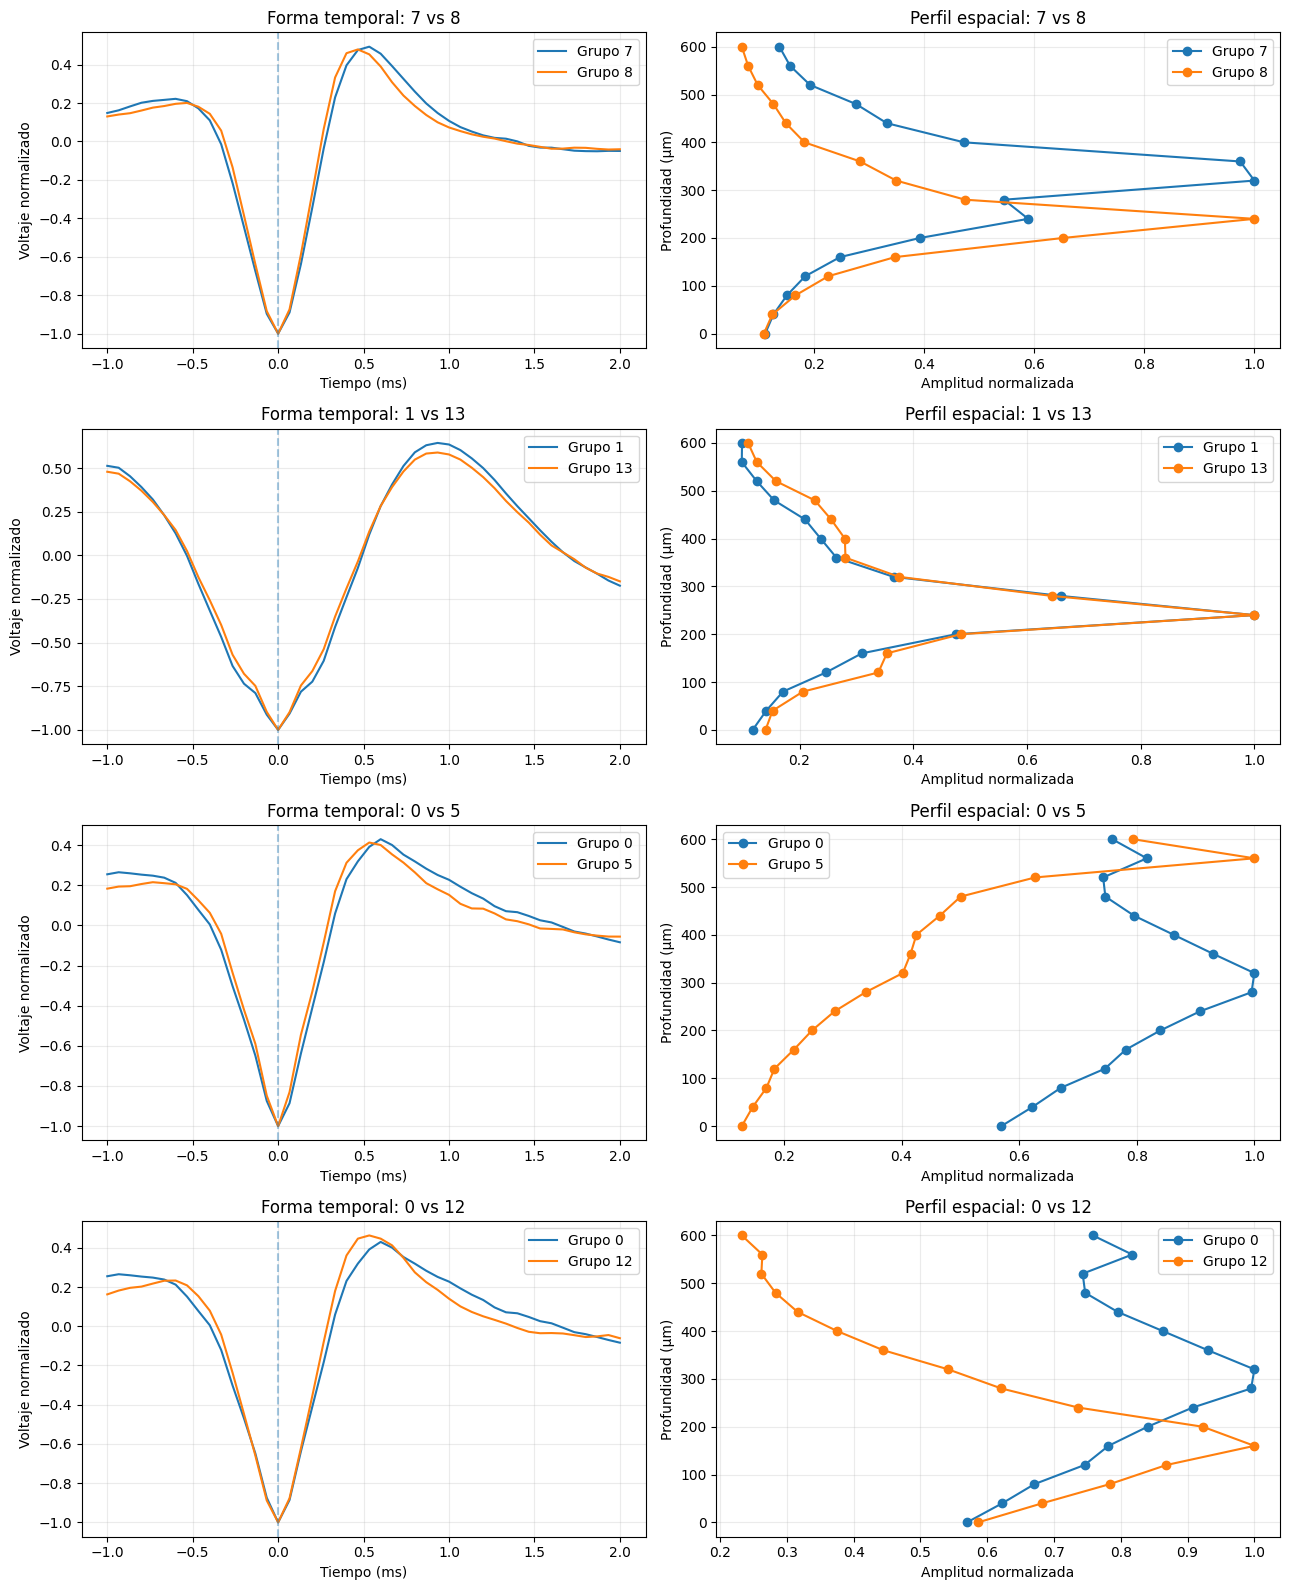

In [ ]:
parejas_revisar = [
    (7, 8),
    (1, 13),
    (0, 5),
    (0, 12)
]

fig, axes = plt.subplots(
    len(parejas_revisar),
    2,
    figsize=(13, 4 * len(parejas_revisar))
)

tiempo_ms = np.arange(formas_v.shape[2]) / fs * 1000 - 1

for fila, (a, b) in enumerate(parejas_revisar):

    forma_a = np.mean(
        formas_v[grupos_final == a],
        axis=0
    )

    forma_b = np.mean(
        formas_v[grupos_final == b],
        axis=0
    )

    # Canal con mayor valle de cada grupo
    canal_a = np.argmin(np.min(forma_a, axis=1))
    canal_b = np.argmin(np.min(forma_b, axis=1))

    # ---------------------------
    # Forma temporal
    # ---------------------------
    onda_a = forma_a[canal_a]
    onda_b = forma_b[canal_b]

    # Normalizar para comparar la FORMA
    onda_a_norm = onda_a / abs(np.min(onda_a))
    onda_b_norm = onda_b / abs(np.min(onda_b))

    axes[fila, 0].plot(
        tiempo_ms,
        onda_a_norm,
        label=f"Grupo {a}"
    )

    axes[fila, 0].plot(
        tiempo_ms,
        onda_b_norm,
        label=f"Grupo {b}"
    )

    axes[fila, 0].axvline(0, linestyle="--", alpha=0.4)
    axes[fila, 0].set_title(f"Forma temporal: {a} vs {b}")
    axes[fila, 0].set_xlabel("Tiempo (ms)")
    axes[fila, 0].set_ylabel("Voltaje normalizado")
    axes[fila, 0].legend()


    # ---------------------------
    # Perfil espacial
    # ---------------------------
    perfil_a = -np.min(forma_a, axis=1)
    perfil_b = -np.min(forma_b, axis=1)

    perfil_a = perfil_a / np.max(perfil_a)
    perfil_b = perfil_b / np.max(perfil_b)

    axes[fila, 1].plot(
        perfil_a,
        y,
        marker="o",
        label=f"Grupo {a}"
    )

    axes[fila, 1].plot(
        perfil_b,
        y,
        marker="o",
        label=f"Grupo {b}"
    )

    axes[fila, 1].set_title(f"Perfil espacial: {a} vs {b}")
    axes[fila, 1].set_xlabel("Amplitud normalizada")
    axes[fila, 1].set_ylabel("Profundidad (µm)")
    axes[fila, 1].legend()

plt.tight_layout()
plt.show()

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos
**ANS -->** b

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:* En el correlograma de los grupos 7 y 8 podemos ver una disminución de eventos entre 0,5 a 2 ms(razón de 0,25), inferior al umbral de 0,35. Sus formas de onda promedio son muy similares, visto tanto en la duración del valle como en la posición del pico positivo. Esto sugiere que podrían corresponder a una misma neurona dividida por K-means. De cualquiermanera, sus perfiles espaciales presentan diferencias, especialmente en la profundidad de máxima amplitud. Lo que mantendría los grupos separados hasta comprobar si las diferencias espaciales corresponden a variabilidad de una misma unidad o a neuronas distintas.



---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

In [ ]:
# ✏️ Ejercicio 7
#A
# Escribir aquí únicamente las fusiones decididas en el ejercicio 6
fusiones = [(1, 13)]
def aplicar_fusiones(grupos, fusiones):
    grupos_nuevos = grupos.copy()

    for a, b in fusiones:
        # Todos los eventos del grupo b pasan al grupo a
        grupos_nuevos[grupos_nuevos == b] = a

    return grupos_nuevos

In [ ]:
grupos_curados = aplicar_fusiones(
    grupos_final,
    fusiones
)

print("Grupos antes:", len(np.unique(grupos_final)))
print("Grupos después:", len(np.unique(grupos_curados)))

Grupos antes: 16
Grupos después: 15


In [ ]:
tabla_curada = calcular_metricas_grupos(
    formas_v,
    tiempos_v,
    canales_v,
    amplitudes_v,
    grupos_curados,
    y,
    datos_filtrados,
    fs=fs,
    k_det=4.5
)

tabla_curada

,grupo,n_disparos,n_picos,n_valles,duracion_us,pendiente_espacial,razon_pico_valle,violaciones_refractario_pct,disparos_faltantes_pct
0,0,1758,1,1,600.000000,-0.006295,0.429998,0.796813,4.481757e+01
1,1,2079,1,1,933.333333,-0.008271,0.615170,1.876805,3.688973e-03
2,2,1115,1,1,466.666667,-0.008447,0.443318,0.897666,1.674903e-08
3,3,1035,1,1,800.000000,-0.008504,0.590562,9.477756,1.329697e-03
4,4,1319,1,1,466.666667,-0.008957,0.485026,0.151745,2.498645e-09
5,5,1483,1,1,533.333333,-0.006934,0.413335,1.282051,3.686489e+01
6,6,734,1,1,933.333333,-0.008657,0.626878,0.409277,1.564618e-09
7,7,1700,1,1,533.333333,-0.008364,0.493330,2.413184,4.985712e-09
8,8,1261,1,1,466.666667,-0.008506,0.478967,0.873016,7.903915e-16
9,9,1361,1,1,800.000000,-0.008199,0.609232,8.529412,2.361657e-05


In [ ]:
#b
def etiquetar_grupo(fila):

    # 1. ¿Parece actividad neuronal?
    es_noise = (
        fila["n_picos"] > 2 or
        fila["n_valles"] > 2 or
        fila["duracion_us"] < 100 or
        fila["duracion_us"] > 1150 or
        fila["pendiente_espacial"] >= -0.004
    )

    if es_noise:
        return "noise"

    # 2. ¿Es una unidad bien aislada y suficientemente completa?
    es_mua = (
        fila["violaciones_refractario_pct"] >= 1.5 or
        fila["disparos_faltantes_pct"] >= 20 or
        fila["n_disparos"] < 300
    )

    if es_mua:
        return "mua"

    # 3. Si pasó lo anterior pero domina el pico positivo
    if fila["razon_pico_valle"] > 0.8:
        return "non-somatic"

    # 4. Pasó todos los criterios
    return "good"

In [ ]:
tabla_curada["etiqueta"] = tabla_curada.apply(
    etiquetar_grupo,
    axis=1
)

tabla_curada[
    ["grupo", "razon_pico_valle", "etiqueta"]
]

,grupo,razon_pico_valle,etiqueta
0,0,0.429998,mua
1,1,0.615170,mua
2,2,0.443318,good
3,3,0.590562,mua
4,4,0.485026,good
5,5,0.413335,mua
6,6,0.626878,good
7,7,0.493330,mua
8,8,0.478967,good
9,9,0.609232,mua


In [ ]:
etiquetas = {
    int(fila["grupo"]): fila["etiqueta"]
    for _, fila in tabla_curada.iterrows()
}

In [ ]:
import verificacion as v

v.usar("taller2_ruidosa.h5")

Verificación configurada con: taller2_ruidosa.h5


In [ ]:
v.verificar_curacion(
    tiempos_v,
    grupos_curados,
    etiquetas
)

  grupo   su etiqueta     correcta      de qué está hecho
  0       mua          ok mua          91% de MUA   n=1758
  1       mua          <-- good         76% de U4   n=2079
  2       good         ok good         83% de U3   n=1115
  3       mua          ok mua          46% de U6   n=1035
  4       good         ok good         98% de U1   n=1319
  5       mua          ok mua          51% de U7   n=1483
  6       good         ok good         84% de U2   n=734
  7       mua          ok mua          67% de U5   n=1700
  8       good         ok good         81% de U3   n=1261
  9       mua          ok mua          67% de U6   n=1361
  10      mua          ok mua          90% de MUA   n=1007
  11      noise        ok noise        72% de artefacto   n=489
  12      mua          ok mua          95% de MUA   n=1252
  14      mua          <-- nonsomatic   40% de U8   n=1424
  15      good         ok good         84% de U1   n=539

  etiquetas correctas: 13 de 15   ████████████████████████····

0.8666666666666667

In [ ]:
tabla_curada.loc[
    tabla_curada["grupo"].isin([1, 14]),
    [
        "grupo",
        "n_disparos",
        "n_picos",
        "n_valles",
        "duracion_us",
        "pendiente_espacial",
        "razon_pico_valle",
        "violaciones_refractario_pct",
        "disparos_faltantes_pct",
        "etiqueta"
    ]
]

,grupo,n_disparos,n_picos,n_valles,duracion_us,pendiente_espacial,razon_pico_valle,violaciones_refractario_pct,disparos_faltantes_pct,etiqueta
1,1,2079,1,1,933.333333,-0.008271,0.615170,1.876805,0.003689,mua
13,14,1424,2,2,666.666667,-0.008605,0.681561,27.336613,0.000170,mua


In [ ]:
tabla_curada.loc[
    tabla_curada["grupo"].isin([2, 15]),
    [
        "grupo",
        "disparos_faltantes_pct",
        "etiqueta"
    ]
]

,grupo,disparos_faltantes_pct,etiqueta
2,2,1.674903e-08,good
15,15,1.378593e-16,good


In [ ]:
tabla_curada.loc[
    tabla_curada["grupo"].isin([10, 12]),
    [
        "grupo",
        "n_picos",
        "n_valles",
        "duracion_us",
        "pendiente_espacial",
        "razon_pico_valle",
        "violaciones_refractario_pct",
        "disparos_faltantes_pct",
        "etiqueta"
    ]
]

,grupo,n_picos,n_valles,duracion_us,pendiente_espacial,razon_pico_valle,violaciones_refractario_pct,disparos_faltantes_pct,etiqueta
10,10,1,1,733.333333,-0.005792,0.469121,0.397614,33.664309,mua
12,12,1,1,533.333333,-0.005598,0.463067,0.319744,34.493860,mua


In [ ]:
# Revisar la razón pico/valle del grupo 14 usando los 16 canales

idx14 = grupos_curados == 14

formas_14 = formas_v[idx14]

# Forma promedio del grupo: 16 canales x muestras
promedio_14 = np.mean(formas_14, axis=0)

# Valle más negativo de toda la forma promedio
valle_14 = np.min(promedio_14)

# Pico positivo más grande de toda la forma promedio
pico_14 = np.max(promedio_14)

razon_14 = pico_14 / abs(valle_14)

print("Valle:", valle_14)
print("Pico positivo:", pico_14)
print("Razón pico/valle:", razon_14)

Valle: -135.64515585828264
Pico positivo: 92.45042466505514
Razón pico/valle: 0.6815608274404148


In [ ]:
#c
grupos_mostrar = tabla_curada.loc[
    tabla_curada["etiqueta"].isin(["good", "non-somatic"]),
    "grupo"
].to_numpy()

print("Grupos para la figura:", grupos_mostrar)

Grupos para la figura: [1 4 6 8]


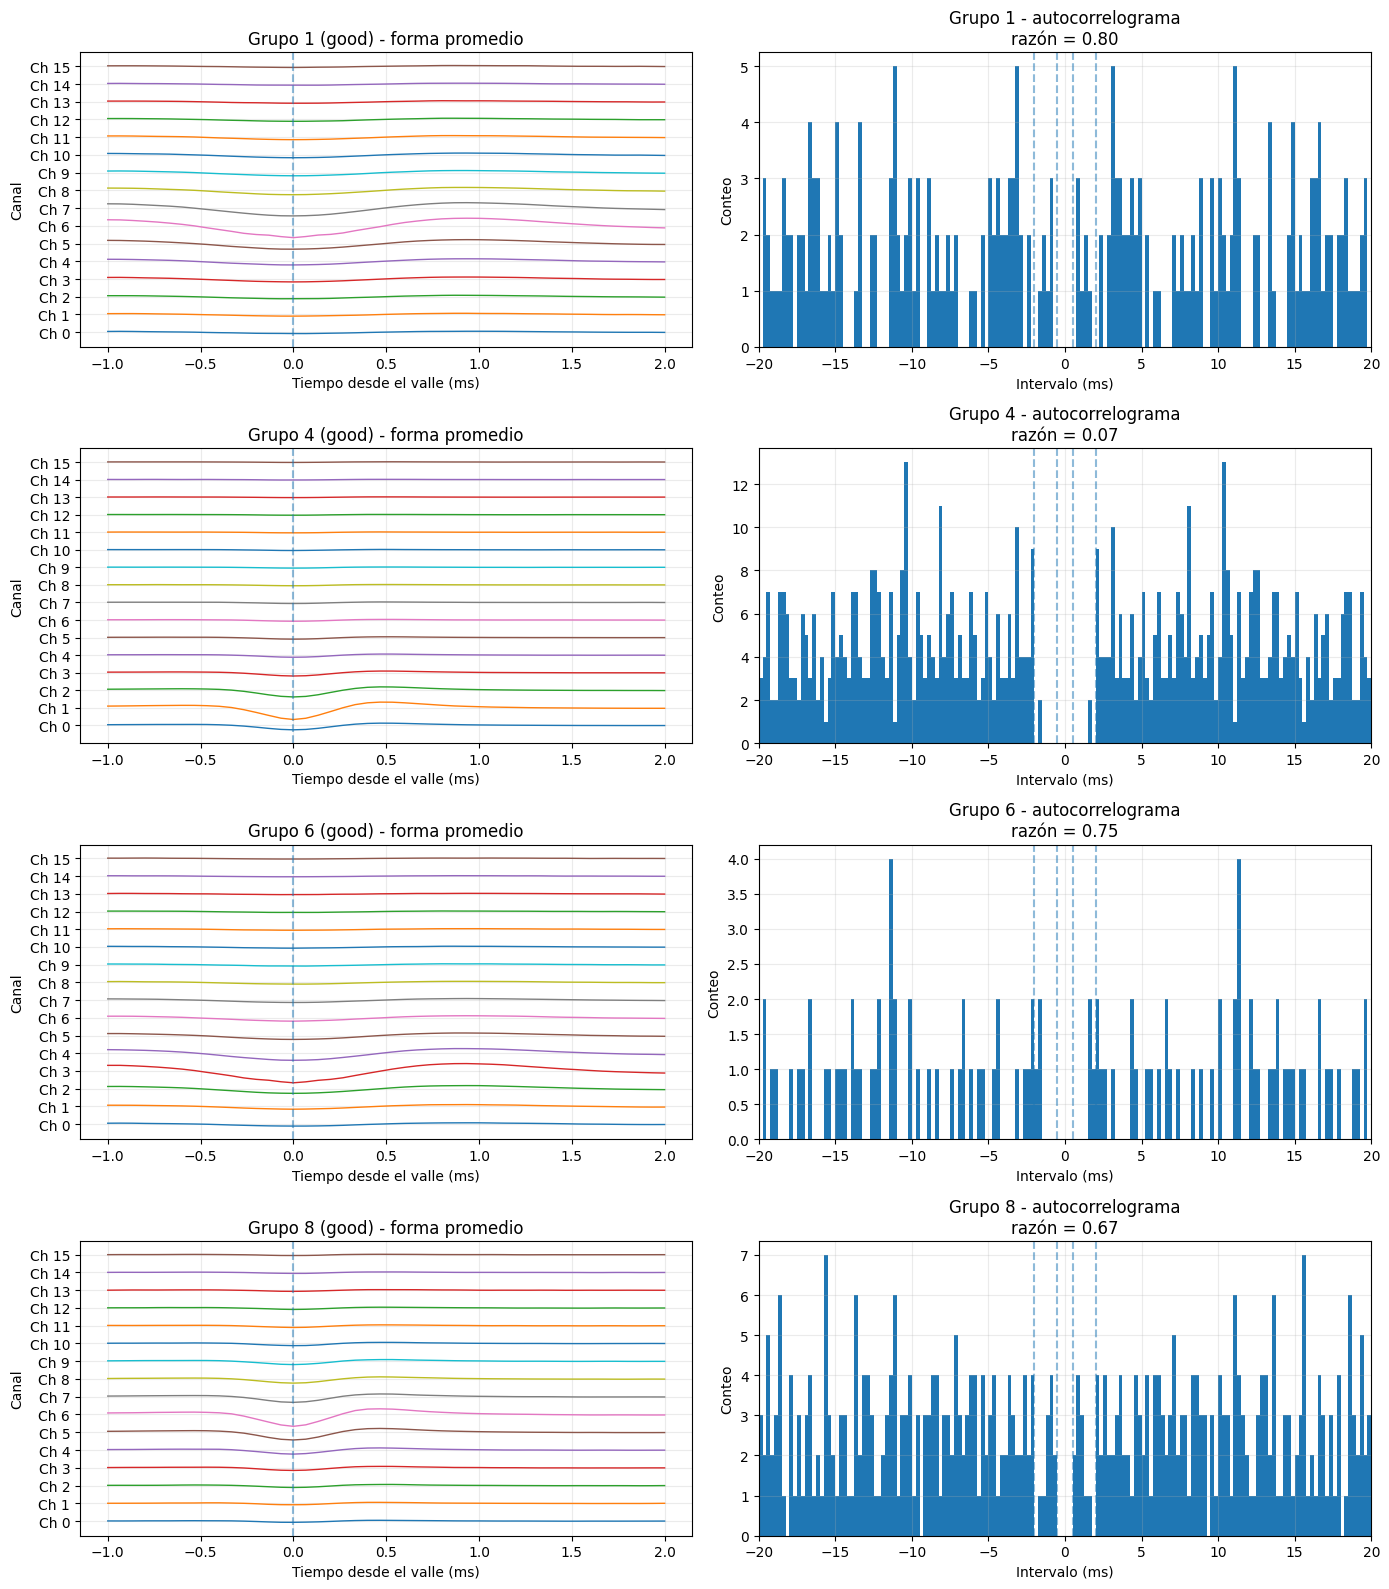

In [ ]:
n = len(grupos_mostrar)

fig, axes = plt.subplots(
    n,
    2,
    figsize=(14, 4 * n)
)

# Por si solo queda un grupo
if n == 1:
    axes = np.array([axes])

tiempo_ms = np.arange(formas_v.shape[2]) / fs * 1000 - 1.0

for fila_fig, grupo in enumerate(grupos_mostrar):

    idx = grupos_curados == grupo

    # ==========================
    # FORMA DE ONDA PROMEDIO
    # ==========================

    formas_g = formas_v[idx]

    # Promedio de cada uno de los 16 canales
    forma_promedio = np.mean(formas_g, axis=0)

    ax = axes[fila_fig, 0]

    # Separación visual entre canales
    separacion = np.max(np.abs(forma_promedio)) * 1.5

    for canal in range(16):
        ax.plot(
            tiempo_ms,
            forma_promedio[canal] + canal * separacion,
            linewidth=1
        )

    ax.axvline(0, linestyle="--", alpha=0.5)

    ax.set_yticks(
        np.arange(16) * separacion
    )

    ax.set_yticklabels(
        [f"Ch {i}" for i in range(16)]
    )

    etiqueta = tabla_curada.loc[
        tabla_curada["grupo"] == grupo,
        "etiqueta"
    ].iloc[0]

    ax.set_title(
        f"Grupo {grupo} ({etiqueta}) - forma promedio"
    )

    ax.set_xlabel("Tiempo desde el valle (ms)")
    ax.set_ylabel("Canal")


    # ==========================
    # AUTOCORRELOGRAMA
    # ==========================

    tiempos_g = tiempos_v[idx]

    centros, conteos, razon = autocorrelograma(
        tiempos_g
    )

    ax = axes[fila_fig, 1]

    ax.bar(
        centros,
        conteos,
        width=0.25
    )

    # Límites de la región refractaria útil
    ax.axvline(-2, linestyle="--", alpha=0.5)
    ax.axvline(-0.5, linestyle="--", alpha=0.5)
    ax.axvline(0.5, linestyle="--", alpha=0.5)
    ax.axvline(2, linestyle="--", alpha=0.5)

    ax.set_xlim(-20, 20)

    ax.set_title(
        f"Grupo {grupo} - autocorrelograma\n"
        f"razón = {razon:.2f}"
    )

    ax.set_xlabel("Intervalo (ms)")
    ax.set_ylabel("Conteo")

plt.tight_layout()
plt.show()

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`

**ANS —>** d

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.


*Su respuesta:*
Good-->
 Grupo 4 :  Presenta una pendiente espacial de −0,008957 µm, unarazón pico/valle de 0,485, y  0,15 % de violaciones refractarias. El  98 % de sus eventos corresponde a U1 y la forma de onda está se encuentra mas que todo en los canales inferiores de la sonda.

Grupo 6:
Tiene una pendiente  de −0,008657  µm, una razón pico/valle de 0,627,  y un 0,41 % de violaciones refractarias. El 84 % de sus eventos corresponde a U2, y la forma de onda presenta un valle definido y una distribución espacial localizada.

Grupo 8: Tiene una razón pico/valle de 0,479, una pendiente espacial de −0,008506  µm y un 0,87 % de violaciones refractarias. En el perfil espacial se ve una señal localizada y el 81 % de sus eventos corresponde a U3.




---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [ ]:
# ✏️ Ejercicio 8
#A
import verificacion as v

v.usar("taller2_ruidosa.h5")

Verificación configurada con: taller2_ruidosa.h5


In [ ]:
# 1. Verificar la detección
v.verificar_deteccion(tiempos_eventos)

  detectados 18639
  verdaderos positivos 18428   falsos positivos 211
  precisión     0.989  ████████████████████████████
  exhaustividad 0.887  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.935  ██████████████████████████··
  faltan 1561 disparos de unidades bien aisladas

  de una unidad identificable  0.654  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 0.9886796501958259,
 'exhaustividad': np.float64(0.8865387410960895),
 'f1': np.float64(0.9348274489011071),
 'util': 0.6543805998175868}

In [ ]:
# 2. Verificar el canal pico
v.verificar_canal_pico(
    tiempos_eventos,
    canales_pico
)

  sobre 18428 detecciones emparejadas:
  canal exacto        0.679  ███████████████████·········
  a un sitio o menos  0.875  █████████████████████████···
  nota: en la actividad multiunitaria el canal pico es inestable por
  naturaleza, así que no espere acertarle a todo.


{'exacto': np.float64(0.6786411981766877),
 'cerca': np.float64(0.8752441936184068)}

In [ ]:
# 3. Verificar las unidades obtenidas
v.verificar_unidades(
    tiempos_v,
    grupos_curados
)

  filas = sus grupos, columnas = la verdad

  grupo        U1     U2     U3     U4     U5     U6     U7     U8    MUA  ruido   nada    n
  0             0      0      0      0      0      1    129      0   1608      4     16   1758
  1             3    130     14   1572      2    134      1     39    176      3      5   2079
  2            73      1    931      6     57      3      1      0     43      0      0   1115
  3             0      0     13     63     30    474      3    197    242      0     13   1035
  4          1296      1      1      0      0      0      0      0     20      0      1   1319
  5             0      0      5      0     17      0    754      5    702      0      0   1483
  6             0    617      1     63      0      2      0      2     48      0      1    734
  7             0      1    392      8   1143     35      5     27     85      0      4   1700
  8             7      0   1022     16    122     10      1      8     74      0      1   1261
  9     

In [ ]:
etiquetas = {
    int(fila["grupo"]): fila["etiqueta"]
    for _, fila in tabla_curada.iterrows()
}

print(etiquetas)

{0: 'mua', 1: 'mua', 2: 'good', 3: 'mua', 4: 'good', 5: 'mua', 6: 'good', 7: 'mua', 8: 'good', 9: 'mua', 10: 'mua', 11: 'noise', 12: 'mua', 14: 'mua', 15: 'good'}


In [ ]:
# 4. Verificar la curación
v.verificar_curacion(
    tiempos_v,
    grupos_curados,
    etiquetas
)

  grupo   su etiqueta     correcta      de qué está hecho
  0       mua          ok mua          91% de MUA   n=1758
  1       mua          <-- good         76% de U4   n=2079
  2       good         ok good         83% de U3   n=1115
  3       mua          ok mua          46% de U6   n=1035
  4       good         ok good         98% de U1   n=1319
  5       mua          ok mua          51% de U7   n=1483
  6       good         ok good         84% de U2   n=734
  7       mua          ok mua          67% de U5   n=1700
  8       good         ok good         81% de U3   n=1261
  9       mua          ok mua          67% de U6   n=1361
  10      mua          ok mua          90% de MUA   n=1007
  11      noise        ok noise        72% de artefacto   n=489
  12      mua          ok mua          95% de MUA   n=1252
  14      mua          <-- nonsomatic   40% de U8   n=1424
  15      good         ok good         84% de U1   n=539

  etiquetas correctas: 13 de 15   ████████████████████████····

0.8666666666666667

In [ ]:
#8b
conservar = np.array([
    etiquetas[int(grupo)] in ["good", "non-somatic"]
    for grupo in grupos_curados
])

In [ ]:
# Grupos que sí llevaríamos al análisis
grupos_conservar = tabla_curada.loc[
    tabla_curada["etiqueta"].isin(["good", "non-somatic"]),
    "grupo"
].to_numpy()

print("Grupos conservados:", grupos_conservar)

Grupos conservados: [ 2  4  6  8 15]


In [ ]:
conservar = np.isin(
    grupos_curados,
    grupos_conservar
)

print("Eventos totales:", len(tiempos_v))
print("Eventos conservados:", np.sum(conservar))

Eventos totales: 18556
Eventos conservados: 4968


In [ ]:
v.verificar_deteccion(
    tiempos_v[conservar]
)

  detectados 4968
  verdaderos positivos 4968   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.346  ██████████··················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.514  ██████████████··············
  faltan 8996 disparos de unidades bien aisladas

  de una unidad identificable  0.959  ███████████████████████████·
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.3461258903910452),
 'f1': np.float64(0.5142548596112311),
 'util': 0.9585346215780999}

Después de la curación se conservaron 4968 eventos, con una precisión de 1.0 y una exhaustividad de 0.346. Aunque se pierden varios disparos de unidades bien aisladas, el 95.9 % de los eventos conservados proviene de unidades identificables, mostrando que la curación elimina gran parte de la actividad multiunitaria y los artefactos antes del análisis.

In [ ]:
print("Eventos antes de curar:", len(tiempos_v))
print("Eventos conservados:", np.sum(conservar))

Eventos antes de curar: 18556
Eventos conservados: 4968


In [ ]:
v.verificar_deteccion(
    tiempos_v[conservar]
)

  detectados 4968
  verdaderos positivos 4968   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.346  ██████████··················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.514  ██████████████··············
  faltan 8996 disparos de unidades bien aisladas

  de una unidad identificable  0.959  ███████████████████████████·
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.3461258903910452),
 'f1': np.float64(0.5142548596112311),
 'util': 0.9585346215780999}

In [ ]:
v.verificar_deteccion(tiempos_eventos)

  detectados 18639
  verdaderos positivos 18428   falsos positivos 211
  precisión     0.989  ████████████████████████████
  exhaustividad 0.887  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.935  ██████████████████████████··
  faltan 1561 disparos de unidades bien aisladas

  de una unidad identificable  0.654  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 0.9886796501958259,
 'exhaustividad': np.float64(0.8865387410960895),
 'f1': np.float64(0.9348274489011071),
 'util': 0.6543805998175868}

In [ ]:
v.verificar_deteccion(tiempos_v[conservar])

  detectados 4968
  verdaderos positivos 4968   falsos positivos 0
  precisión     1.000  ████████████████████████████
  exhaustividad 0.346  ██████████··················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.514  ██████████████··············
  faltan 8996 disparos de unidades bien aisladas

  de una unidad identificable  0.959  ███████████████████████████·
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.


{'precision': 1.0,
 'exhaustividad': np.float64(0.3461258903910452),
 'f1': np.float64(0.5142548596112311),
 'util': 0.9585346215780999}

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

**ANS -->** b

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:*
La fracción de eventos que vienen de una unidad identificable aumentó de 65,4 % a 95,9 % ( un tottal de 30,5 puntos porcentuales). Se recuperaron cinco grupos clasificados como "good" de las ocho unidades originales. La matriz muestra que algunas unidades quedaron divididas entre diferentes grupos (U1 y U3), mientras que otros (U4, U5, U6 y U7), quedaron en grupos como mua y fueron descartados durante la curación. Por edne, aumenta la proporción de eventos identificables, pero se perdie una parte de los disparos verdaderos.


---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

In [ ]:
with h5py.File("taller2_ruidosa.h5", "r") as f:
    print("Estructura completa:")
    f.visit(print)

Estructura completa:
estimulos
estimulos/condicion
estimulos/tiempo_inicio_s
geometria
geometria/canal_x_um
geometria/canal_y_um
registro
registro/datos
verdad
verdad/artefactos_lentos_s
verdad/canal_pico
verdad/clase_objetivo
verdad/perfil_uv
verdad/pt_ms
verdad/tiempos_s
verdad/unidad
verdad/unidades_buenas


In [ ]:
with h5py.File("taller2_ruidosa.h5", "r") as f:
    for grupo in f.keys():
        print("\nGRUPO:", grupo)

        print("Atributos:")
        for clave, valor in f[grupo].attrs.items():
            print(" ", clave, "=", valor)

        for nombre in f[grupo].keys():
            obj = f[grupo][nombre]

            if isinstance(obj, h5py.Dataset):
                print(
                    f"  {nombre}: shape={obj.shape}, dtype={obj.dtype}"
                )


GRUPO: estimulos
Atributos:
  duracion_estimulo_s = 0.5
  duracion_post_s = 1.5
  duracion_pre_s = 1.0
  nota = tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues.
  condicion: shape=(60,), dtype=|S1
  tiempo_inicio_s: shape=(60,), dtype=float64

GRUPO: geometria
Atributos:
  nota = Sonda lineal de 16 sitios separados 50 um. canal_y_um es la profundidad de cada sitio.
  canal_x_um: shape=(16,), dtype=float64
  canal_y_um: shape=(16,), dtype=float64

GRUPO: registro
Atributos:
  forma = canales x muestras
  datos: shape=(16, 3000000), dtype=int16

GRUPO: verdad
Atributos:
  nota = unidad: 1..N = unidad bien aislada (good); 0 = neurona de fondo (MUA); -1 = artefacto (noise). Los cruces del umbral por ruido termico no estan aqui: no son potenciales de accion.
  artefactos_lentos_s: shape=(5,), dtype=float64
  canal_pico: shape=(84328,), dtype=int8
  clase_objetivo: shape=(8,), dtype=|S12
  perfil_uv: shape=(8, 16), dtype=float32
  pt_ms: shape=(8,), dt

In [ ]:
# ✏️ Ejercicio 9
#a
with h5py.File("taller2_ruidosa.h5", "r") as f:
    inicios_ensayo = f["estimulos/tiempo_inicio_s"][:]
    condiciones = f["estimulos/condicion"][:].astype(str)

    pre_s = f["estimulos"].attrs["duracion_pre_s"]
    duracion_estimulo_s = f["estimulos"].attrs["duracion_estimulo_s"]
    post_s = f["estimulos"].attrs["duracion_post_s"]

print("Número de ensayos:", len(inicios_ensayo))
print("Condiciones:", np.unique(condiciones, return_counts=True))

Número de ensayos: 60
Condiciones: (array(['A', 'B', 'C'], dtype='<U1'), array([20, 20, 20]))


In [ ]:
def tiempos_relativos_por_ensayo(
    tiempos_spikes,
    inicios_ensayo,
    condiciones,
    pre_s=1.0,
    duracion_estimulo_s=0.5,
    post_s=1.5
):
    relativos = []

    duracion_total = pre_s + duracion_estimulo_s + post_s

    for inicio, condicion in zip(inicios_ensayo, condiciones):

        # El estímulo empieza 1 s después del inicio del ensayo
        inicio_estimulo = inicio + pre_s

        # Buscar spikes que ocurrieron dentro de este ensayo
        dentro = (
            (tiempos_spikes >= inicio) &
            (tiempos_spikes < inicio + duracion_total)
        )

        # Restar el inicio del estímulo:
        # ahora 0 s = comienzo del estímulo
        spikes_relativos = (
            tiempos_spikes[dentro] - inicio_estimulo
        )

        relativos.append(spikes_relativos)

    return relativos

In [ ]:
grupos_good = tabla_curada.loc[
    tabla_curada["etiqueta"] == "good",
    "grupo"
].to_numpy()

print("Grupos good:", grupos_good)

Grupos good: [ 2  4  6  8 15]


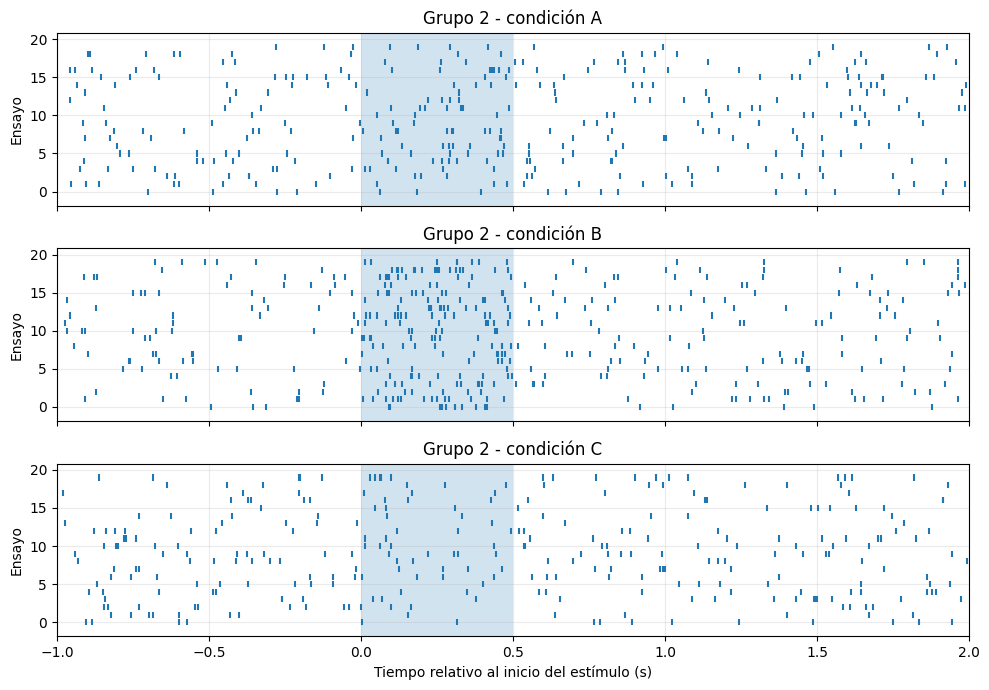

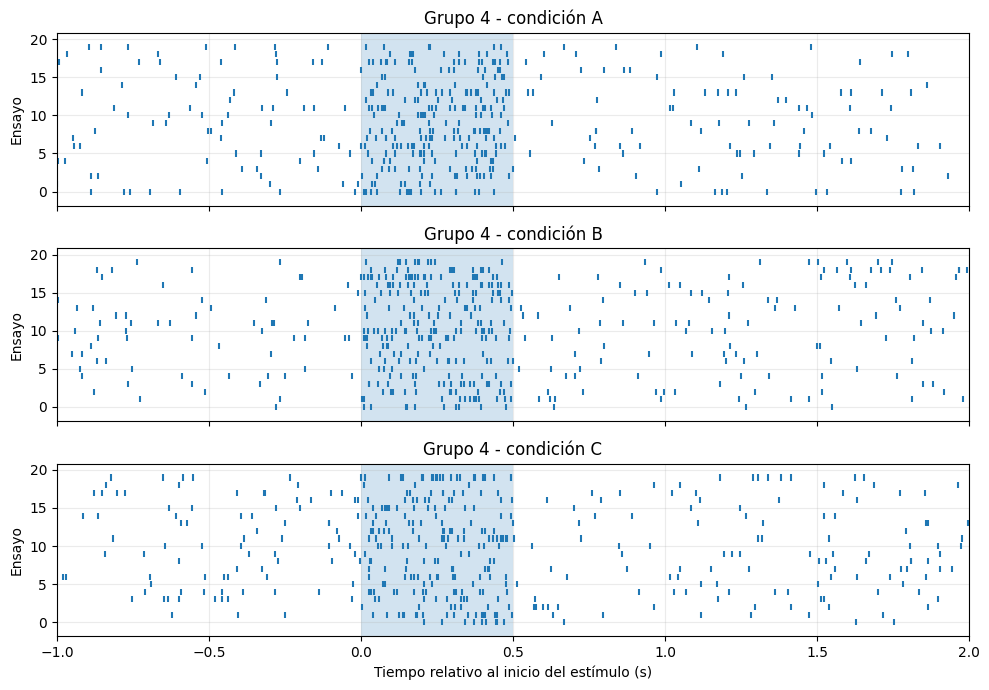

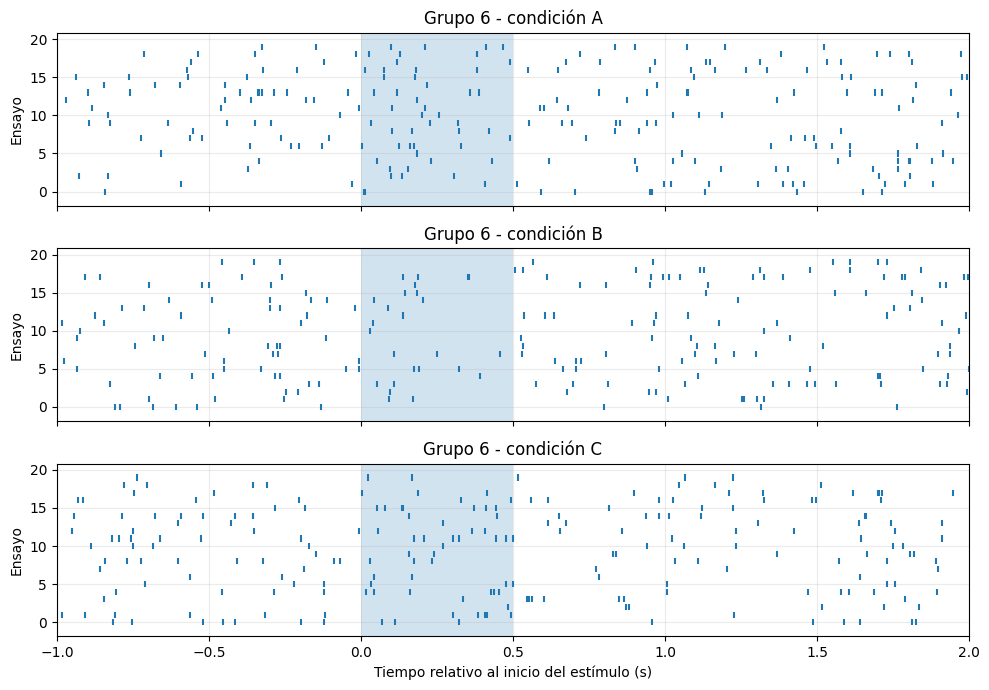

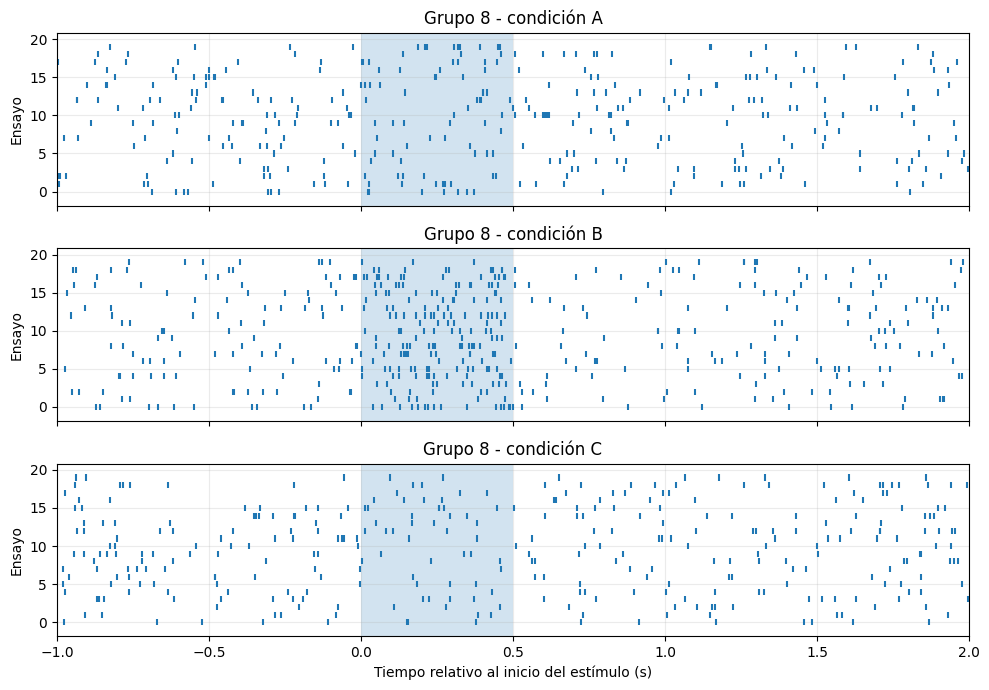

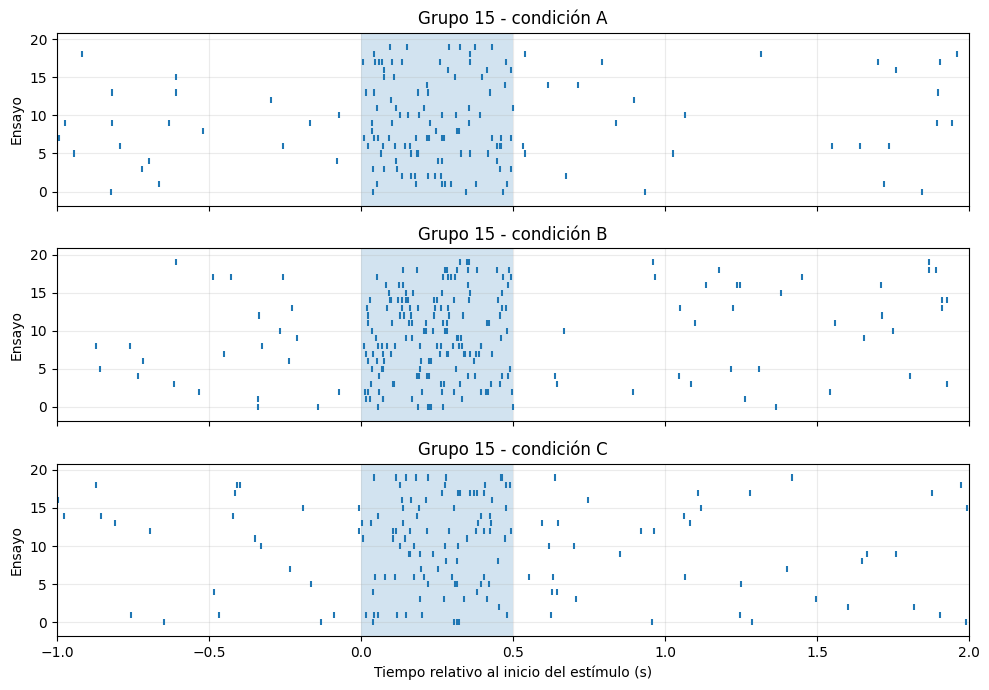

In [ ]:
#b
condiciones_unicas = np.unique(condiciones)

for grupo in grupos_good:

    # Tiempos absolutos de los spikes de esta unidad
    tiempos_unidad = tiempos_v[
        grupos_curados == grupo
    ]

    # Pasarlos a tiempos relativos al estímulo
    relativos = tiempos_relativos_por_ensayo(
        tiempos_unidad,
        inicios_ensayo,
        condiciones,
        pre_s=pre_s,
        duracion_estimulo_s=duracion_estimulo_s,
        post_s=post_s
    )

    fig, axes = plt.subplots(
        len(condiciones_unicas),
        1,
        figsize=(10, 7),
        sharex=True
    )

    for ax, condicion in zip(axes, condiciones_unicas):

        # Ensayos que pertenecen a esta condición
        indices = np.where(condiciones == condicion)[0]

        spikes_condicion = [
            relativos[i]
            for i in indices
        ]

        # Raster
        ax.eventplot(
            spikes_condicion,
            lineoffsets=np.arange(len(spikes_condicion)),
            linelengths=0.8
        )

        # Marcar duración del estímulo
        ax.axvspan(
            0,
            duracion_estimulo_s,
            alpha=0.2
        )

        ax.set_ylabel("Ensayo")
        ax.set_title(
            f"Grupo {grupo} - condición {condicion}"
        )

    axes[-1].set_xlabel(
        "Tiempo relativo al inicio del estímulo (s)"
    )

    axes[-1].set_xlim(
        -pre_s,
        duracion_estimulo_s + post_s
    )

    plt.tight_layout()
    plt.show()

In [ ]:
#c
def calcular_psth(
    relativos,
    condiciones,
    condicion,
    pre_s=1.0,
    duracion_estimulo_s=0.5,
    post_s=1.5,
    bin_ms=50
):
    bin_s = bin_ms / 1000

    indices = np.where(
        condiciones == condicion
    )[0]

    ensayos = [
        relativos[i]
        for i in indices
    ]

    # Juntar los spikes de todos los ensayos
    if len(ensayos) > 0:
        todos_spikes = np.concatenate(ensayos)
    else:
        todos_spikes = np.array([])

    bins = np.arange(
        -pre_s,
        duracion_estimulo_s + post_s + bin_s,
        bin_s
    )

    conteos, bordes = np.histogram(
        todos_spikes,
        bins=bins
    )

    centros = (
        bordes[:-1] + bordes[1:]
    ) / 2

    # Convertir el conteo a tasa de disparo en Hz
    tasa_hz = conteos / (
        len(ensayos) * bin_s
    )

    return centros, tasa_hz

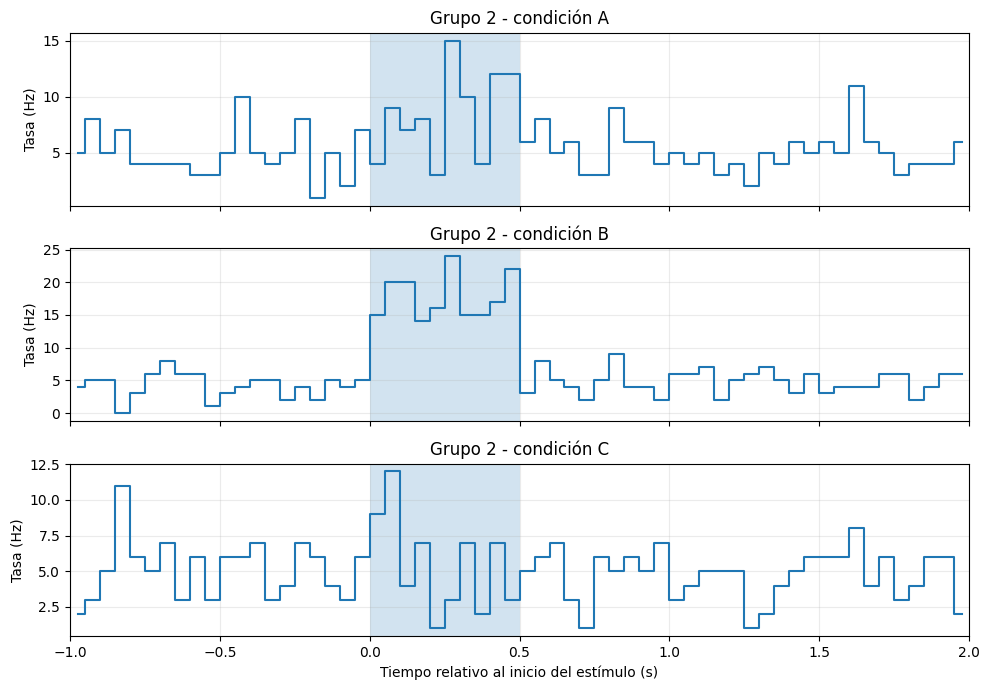

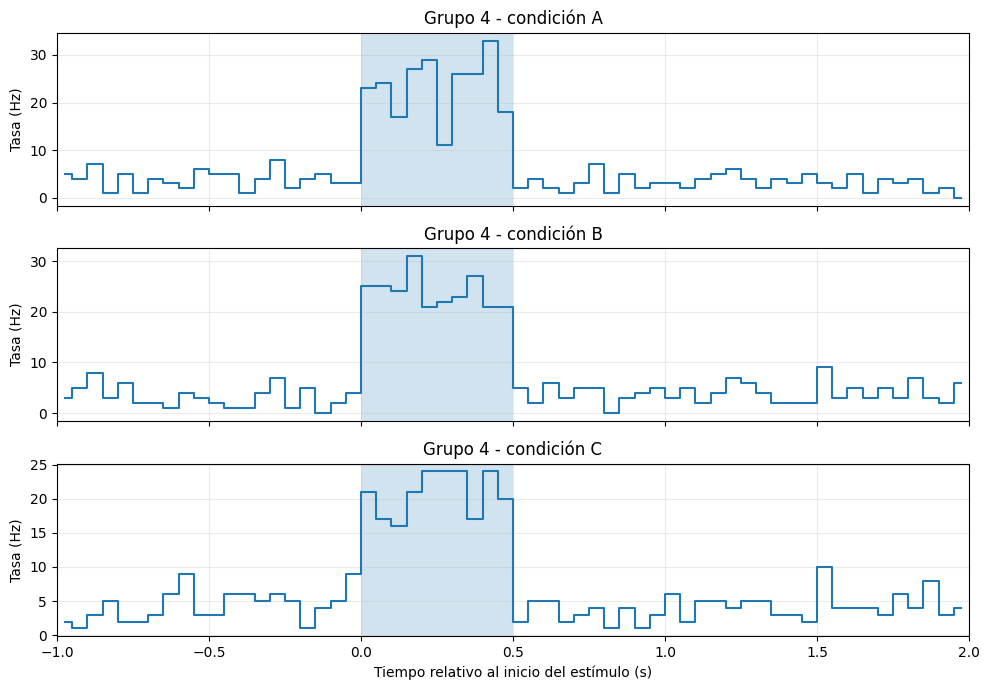

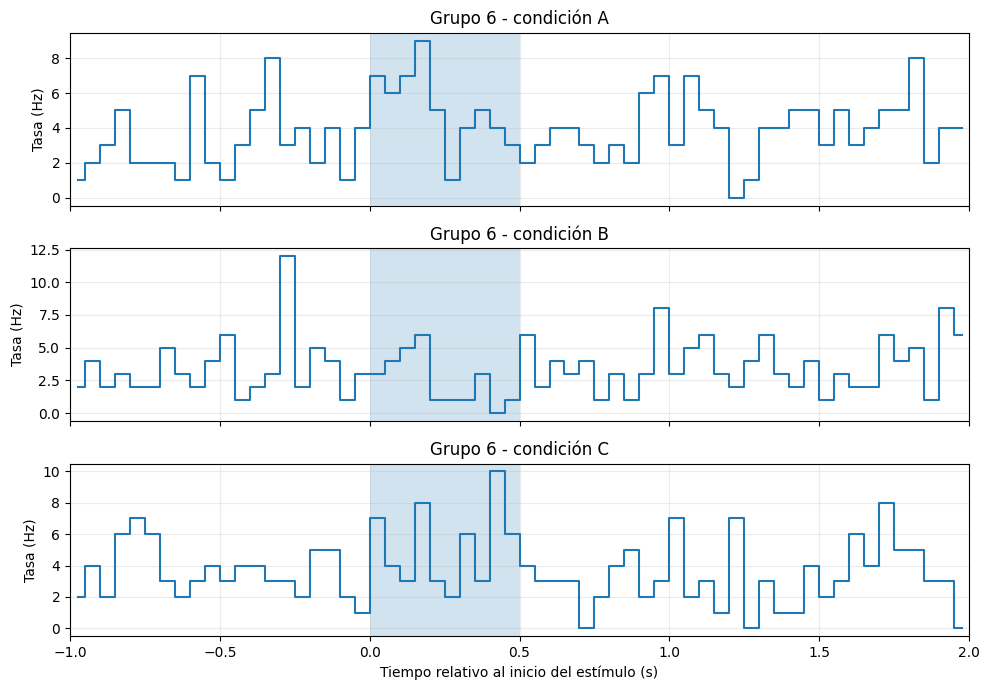

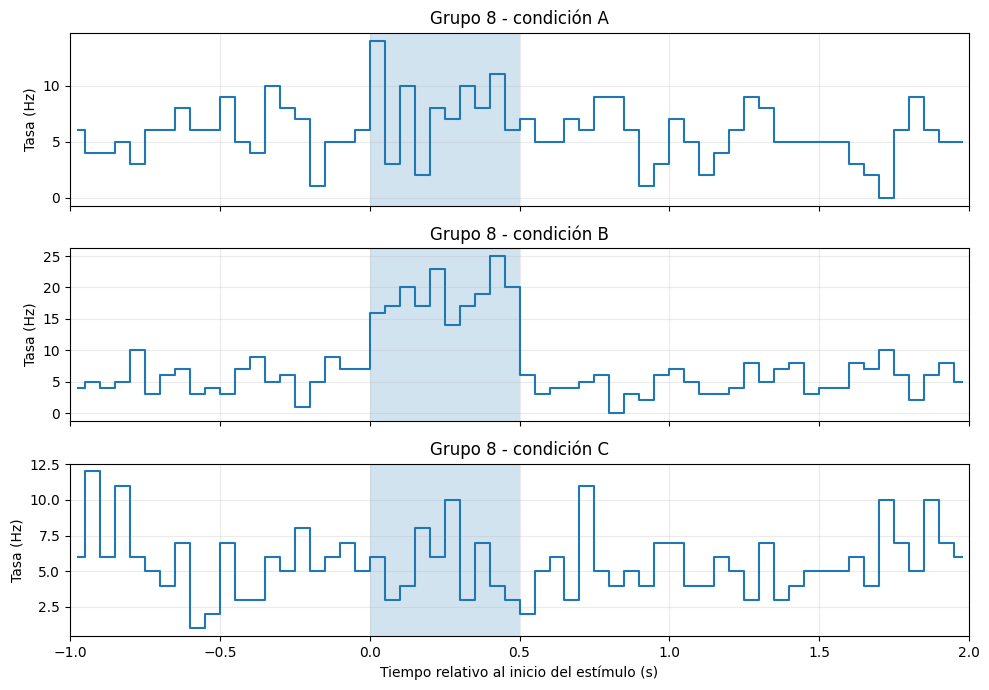

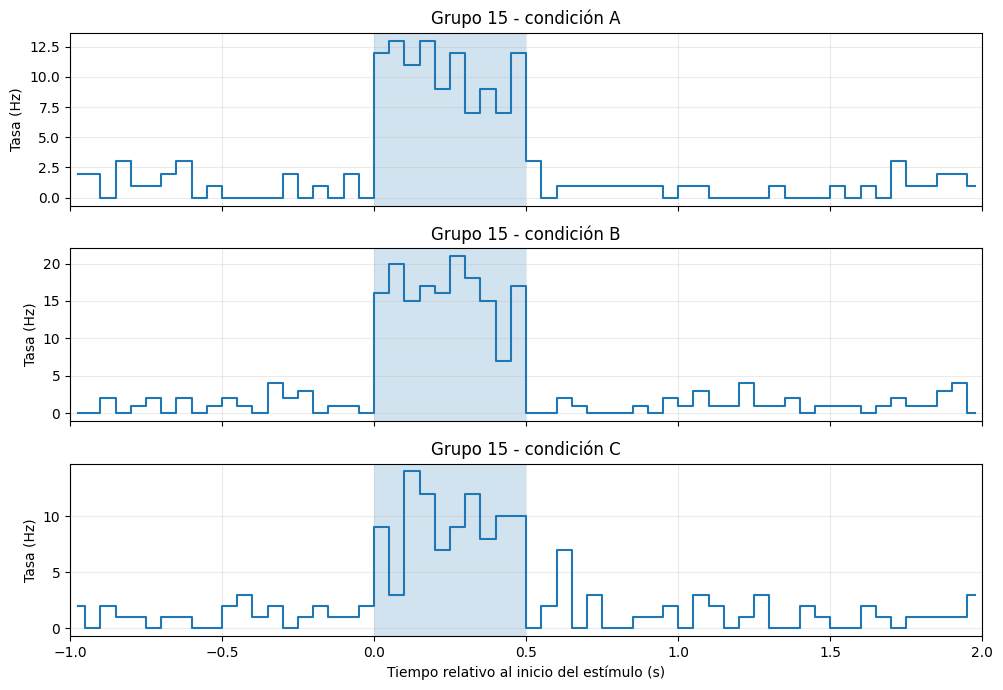

In [ ]:
for grupo in grupos_good:

    tiempos_unidad = tiempos_v[
        grupos_curados == grupo
    ]

    relativos = tiempos_relativos_por_ensayo(
        tiempos_unidad,
        inicios_ensayo,
        condiciones,
        pre_s=pre_s,
        duracion_estimulo_s=duracion_estimulo_s,
        post_s=post_s
    )

    fig, axes = plt.subplots(
        len(condiciones_unicas),
        1,
        figsize=(10, 7),
        sharex=True
    )

    for ax, condicion in zip(
        axes,
        condiciones_unicas
    ):

        centros, tasa = calcular_psth(
            relativos,
            condiciones,
            condicion,
            pre_s=pre_s,
            duracion_estimulo_s=duracion_estimulo_s,
            post_s=post_s,
            bin_ms=50
        )

        ax.step(
            centros,
            tasa,
            where="mid"
        )

        ax.axvspan(
            0,
            duracion_estimulo_s,
            alpha=0.2
        )

        ax.set_ylabel("Tasa (Hz)")
        ax.set_title(
            f"Grupo {grupo} - condición {condicion}"
        )

    axes[-1].set_xlabel(
        "Tiempo relativo al inicio del estímulo (s)"
    )

    axes[-1].set_xlim(
        -pre_s,
        duracion_estimulo_s + post_s
    )

    plt.tight_layout()
    plt.show()

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

**ANS -->** b

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*
Los grupos 4 y 15 presentan una acumulación de disparos durante el estímulo en las tres condiciones, mientras que los grupos 2 y 8 muestran una respuesta más marcada en B. El grupo 6 mantiene una actividad relativamente dispersa, sin un aumento consistente durante el estímulo.
Una ventana de 50 ms (0,05 s) para representar el PSTH, ay que permite observar los cambios en la tasa de disparo durante los 500 ms del estímulo sin perder mucha resolución temporal.

---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [ ]:
import pandas as pd
from scipy.stats import ttest_rel

In [ ]:
def tasas_por_ensayo(
    tiempos_spikes,
    inicios_ensayo,
    condiciones,
    pre_s=1.0,
    duracion_estimulo_s=0.5
):
    filas = []

    for i, (inicio, condicion) in enumerate(
        zip(inicios_ensayo, condiciones)
    ):

        inicio_estimulo = inicio + pre_s

        # Basal: segundo anterior al estímulo
        n_basal = np.sum(
            (tiempos_spikes >= inicio) &
            (tiempos_spikes < inicio_estimulo)
        )

        # Durante el estímulo
        n_estimulo = np.sum(
            (tiempos_spikes >= inicio_estimulo) &
            (tiempos_spikes < inicio_estimulo + duracion_estimulo_s)
        )

        # Convertir conteos a Hz
        tasa_basal = n_basal / pre_s
        tasa_estimulo = n_estimulo / duracion_estimulo_s

        filas.append({
            "ensayo": i,
            "condicion": condicion,
            "tasa_basal_hz": tasa_basal,
            "tasa_estimulo_hz": tasa_estimulo
        })

    return pd.DataFrame(filas)

In [ ]:
grupos_good = tabla_curada.loc[
    tabla_curada["etiqueta"] == "good",
    "grupo"
].to_numpy()

print("Grupos good:", grupos_good)

Grupos good: [ 2  4  6  8 15]


In [ ]:
tablas_ensayos = []

for grupo in grupos_good:

    tiempos_unidad = tiempos_v[
        grupos_curados == grupo
    ]

    tabla_g = tasas_por_ensayo(
        tiempos_unidad,
        inicios_ensayo,
        condiciones,
        pre_s=pre_s,
        duracion_estimulo_s=duracion_estimulo_s
    )

    tabla_g.insert(0, "grupo", grupo)

    tablas_ensayos.append(tabla_g)

tabla_ensayos = pd.concat(
    tablas_ensayos,
    ignore_index=True
)

tabla_ensayos

,grupo,ensayo,condicion,tasa_basal_hz,tasa_estimulo_hz
0,2,0,C,4.0,4.0
1,2,1,C,7.0,2.0
2,2,2,B,3.0,22.0
3,2,3,B,5.0,28.0
4,2,4,B,4.0,12.0
...,...,...,...,...,...
295,15,55,A,0.0,8.0
296,15,56,A,0.0,18.0
297,15,57,A,1.0,4.0
298,15,58,B,1.0,6.0


In [ ]:
# ✏️ Ejercicio 10
#b y d
def bootstrap_media(valores, n_boot=5000, semilla=42):
    rng = np.random.default_rng(semilla)

    valores = np.asarray(valores)

    medias_boot = np.empty(n_boot)

    for i in range(n_boot):
        muestra = rng.choice(
            valores,
            size=len(valores),
            replace=True
        )

        medias_boot[i] = np.mean(muestra)

    ic_bajo, ic_alto = np.percentile(
        medias_boot,
        [2.5, 97.5]
    )

    return ic_bajo, ic_alto

In [ ]:
filas_resumen = []

for grupo in grupos_good:

    datos_grupo = tabla_ensayos[
        tabla_ensayos["grupo"] == grupo
    ]

    # Basal de la unidad usando TODOS los ensayos
    basal_total = datos_grupo["tasa_basal_hz"].to_numpy()

    media_basal_unidad = np.mean(basal_total)
    sd_basal_unidad = np.std(
        basal_total,
        ddof=1
    )

    for condicion in np.unique(condiciones):

        datos_cond = datos_grupo[
            datos_grupo["condicion"] == condicion
        ]

        basal = datos_cond[
            "tasa_basal_hz"
        ].to_numpy()

        estimulo = datos_cond[
            "tasa_estimulo_hz"
        ].to_numpy()

        media_basal = np.mean(basal)
        media_estimulo = np.mean(estimulo)

        # ----------------------
        # Z-score
        # ----------------------
        if sd_basal_unidad > 0:
            z = (
                media_estimulo - media_basal_unidad
            ) / sd_basal_unidad
        else:
            z = np.nan

        # ----------------------
        # t-test pareado
        # ----------------------
        t_stat, p_valor = ttest_rel(
            estimulo,
            basal
        )

        # ----------------------
        # Bootstrap de la tasa evocada
        # ----------------------
        ic_bajo, ic_alto = bootstrap_media(
            estimulo,
            n_boot=5000,
            semilla=42
        )

        filas_resumen.append({
            "grupo": grupo,
            "condicion": condicion,
            "n_ensayos": len(datos_cond),

            "basal_media_hz": media_basal,
            "estimulo_media_hz": media_estimulo,

            "z_score": z,

            "t": t_stat,
            "p": p_valor,

            "IC95_bajo_hz": ic_bajo,
            "IC95_alto_hz": ic_alto
        })

tabla_ej10 = pd.DataFrame(filas_resumen)

tabla_ej10

,grupo,condicion,n_ensayos,basal_media_hz,estimulo_media_hz,z_score,t,p,IC95_bajo_hz,IC95_alto_hz
0,2,A,20,4.95,8.4,1.683771,3.209988,4.609785e-03,6.7000,10.3000
1,2,B,20,4.15,17.8,6.020059,8.558788,6.061181e-08,15.3000,20.5000
2,2,C,20,5.15,5.5,0.345980,0.470200,6.435647e-01,4.5000,6.5000
3,4,A,20,3.90,23.4,9.135182,10.403651,2.771862e-09,19.6000,27.3000
4,4,B,20,3.20,24.0,9.414830,8.803682,3.930634e-08,19.7000,28.6000
5,4,C,20,4.30,20.8,7.923372,7.342404,5.848022e-07,16.8000,25.3025
6,6,A,20,3.10,5.1,0.879389,2.955610,8.120734e-03,4.0000,6.2000
7,6,B,20,3.40,2.5,-0.427132,-1.528187,1.429434e-01,1.6000,3.5000
8,6,C,20,3.55,5.2,0.929640,1.861518,7.821472e-02,3.6000,6.9000
9,8,A,20,5.70,7.9,0.960662,2.157277,4.399958e-02,5.9000,9.9000


In [ ]:
tabla_ej10.round(3)

,grupo,condicion,n_ensayos,basal_media_hz,estimulo_media_hz,z_score,t,p,IC95_bajo_hz,IC95_alto_hz
0,2,A,20,4.95,8.4,1.684,3.210,0.005,6.700,10.300
1,2,B,20,4.15,17.8,6.020,8.559,0.000,15.300,20.500
2,2,C,20,5.15,5.5,0.346,0.470,0.644,4.500,6.500
3,4,A,20,3.90,23.4,9.135,10.404,0.000,19.600,27.300
4,4,B,20,3.20,24.0,9.415,8.804,0.000,19.700,28.600
5,4,C,20,4.30,20.8,7.923,7.342,0.000,16.800,25.302
6,6,A,20,3.10,5.1,0.879,2.956,0.008,4.000,6.200
7,6,B,20,3.40,2.5,-0.427,-1.528,0.143,1.600,3.500
8,6,C,20,3.55,5.2,0.930,1.862,0.078,3.600,6.900
9,8,A,20,5.70,7.9,0.961,2.157,0.044,5.900,9.900


In [ ]:
tabla_ej10[
    ["grupo", "condicion", "n_ensayos"]
]

,grupo,condicion,n_ensayos
0,2,A,20
1,2,B,20
2,2,C,20
3,4,A,20
4,4,B,20
5,4,C,20
6,6,A,20
7,6,B,20
8,6,C,20
9,8,A,20


**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

**ANS -->** b

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*
El grupo 4 presenta un aumento estadísticamente significativo de la actividad durante el estímulo. Su valor de t elevado demuestra que el aumento medio es grande en relación con la variabilidad entre ensayos. En cambio, el grupo 8 en la condición C tiene una tasa durante el estímulo muy parecida a su tasa basal ( valor t cercano a cero y p elevado).

Sí, ya que el intervalo de confianza del 95 % del grupo 8 en la condición C es de 4,2 a 6,6 Hz e incluye su tasa basal de 5,75 Hz. Esto es consistente con el resultado del t-test (p = 0,682): no se detecta un cambio significativo de la actividad neuronal durante el estímulo.

Por el contrario, el intervalo del grupo 4 en la condición B (19,7 a28,6 Hz) está completamente por encima de su tasa basal de 3,2 Hz, lo que respalda la presencia de una respuesta evocada significativa.


---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

In [ ]:
# ✏️ Ejercicio 11
cent = centroides[validos]
centroides_evento = cent
print("Centroides:", len(centroides_evento))
print("Formas:", len(formas_v))
print("Grupos:", len(grupos_curados))

Centroides: 18556
Formas: 18556
Grupos: 18556


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# -----------------------------
# Configuración general
# -----------------------------
grupos_good = tabla_curada.loc[
    tabla_curada["etiqueta"] == "good",
    "grupo"
].to_numpy()

grupo_raster = 6   # buena candidata para Panel B

condiciones_unicas = ["A", "B", "C"]
colores = {
    "A": "tab:blue",
    "B": "tab:orange",
    "C": "tab:purple"
}

# Si tu variable de centroides por evento tiene otro nombre, cámbiala aquí
centroides_evento = cent

tiempo_ms = np.arange(formas_v.shape[2]) / fs * 1000 - 1.0

In [ ]:
def onda_promedio_grupo(grupo):
    """
    Devuelve:
    - onda promedio del canal representativo
    - forma promedio de los 16 canales
    - canal representativo
    """
    formas_g = formas_v[grupos_curados == grupo]
    forma_prom_16 = np.mean(formas_g, axis=0)

    canal_rep = np.argmin(np.min(forma_prom_16, axis=1))
    onda_rep = forma_prom_16[canal_rep]

    return onda_rep, forma_prom_16, canal_rep


def tiempos_relativos_por_ensayo(
    tiempos_spikes,
    inicios_ensayo,
    condiciones,
    pre_s=1.0,
    duracion_estimulo_s=0.5,
    post_s=1.5
):
    relativos = []
    duracion_total = pre_s + duracion_estimulo_s + post_s

    for inicio, condicion in zip(inicios_ensayo, condiciones):
        inicio_estimulo = inicio + pre_s

        dentro = (
            (tiempos_spikes >= inicio) &
            (tiempos_spikes < inicio + duracion_total)
        )

        spikes_relativos = tiempos_spikes[dentro] - inicio_estimulo
        relativos.append(spikes_relativos)

    return relativos


def psth_unidad_condicion(
    grupo,
    condicion_obj,
    bin_ms=50,
    pre_s=1.0,
    duracion_estimulo_s=0.5,
    post_s=1.5
):
    tiempos_unidad = tiempos_v[grupos_curados == grupo]

    relativos = tiempos_relativos_por_ensayo(
        tiempos_unidad,
        inicios_ensayo,
        condiciones,
        pre_s=pre_s,
        duracion_estimulo_s=duracion_estimulo_s,
        post_s=post_s
    )

    idx = np.where(np.array(condiciones) == condicion_obj)[0]
    ensayos = [relativos[i] for i in idx]

    if len(ensayos) > 0:
        todos = np.concatenate(ensayos)
    else:
        todos = np.array([])

    bin_s = bin_ms / 1000
    bins = np.arange(-pre_s, duracion_estimulo_s + post_s + bin_s, bin_s)

    conteos, bordes = np.histogram(todos, bins=bins)
    centros = (bordes[:-1] + bordes[1:]) / 2

    tasa_hz = conteos / (len(ensayos) * bin_s)
    return centros, tasa_hz


def bootstrap_media(valores, n_boot=5000, semilla=42):
    rng = np.random.default_rng(semilla)
    valores = np.asarray(valores)

    medias = np.empty(n_boot)

    for i in range(n_boot):
        muestra = rng.choice(valores, size=len(valores), replace=True)
        medias[i] = np.mean(muestra)

    lo, hi = np.percentile(medias, [2.5, 97.5])
    return lo, hi


def bootstrap_psth(matriz, n_boot=5000, semilla=42):
    """
    matriz: n_unidades x n_bins
    Bootstrap sobre unidades
    """
    rng = np.random.default_rng(semilla)

    n_unidades = matriz.shape[0]
    medias_boot = np.empty((n_boot, matriz.shape[1]))

    for i in range(n_boot):
        idx = rng.choice(n_unidades, size=n_unidades, replace=True)
        medias_boot[i] = np.mean(matriz[idx], axis=0)

    lo = np.percentile(medias_boot, 2.5, axis=0)
    hi = np.percentile(medias_boot, 97.5, axis=0)
    return lo, hi

In [ ]:
resumen_unidades = []

for grupo in grupos_good:
    centroide_medio = np.mean(
        centroides_evento[grupos_curados == grupo]
    )

    onda_rep, forma_prom_16, canal_rep = onda_promedio_grupo(grupo)

    resumen_unidades.append({
        "grupo": grupo,
        "centroide_um": centroide_medio,
        "onda_rep": onda_rep,
        "canal_rep": canal_rep
    })

# Ordenarlas por profundidad
resumen_unidades = sorted(
    resumen_unidades,
    key=lambda x: x["centroide_um"]
)

In [ ]:
bin_ms = 50

psth_general = {}

for cond in condiciones_unicas:
    matriz = []

    for grupo in grupos_good:
        centros, tasa = psth_unidad_condicion(
            grupo,
            cond,
            bin_ms=bin_ms,
            pre_s=pre_s,
            duracion_estimulo_s=duracion_estimulo_s,
            post_s=post_s
        )
        matriz.append(tasa)

    matriz = np.vstack(matriz)
    media = np.mean(matriz, axis=0)
    lo, hi = bootstrap_psth(matriz, n_boot=5000, semilla=42)

    psth_general[cond] = {
        "centros": centros,
        "media": media,
        "lo": lo,
        "hi": hi
    }

In [ ]:
swarm_df = (
    tabla_ensayos[tabla_ensayos["grupo"].isin(grupos_good)]
    .groupby(["condicion", "ensayo"], as_index=False)["tasa_estimulo_hz"]
    .mean()
)

/tmp/ipykernel_1236/579912246.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


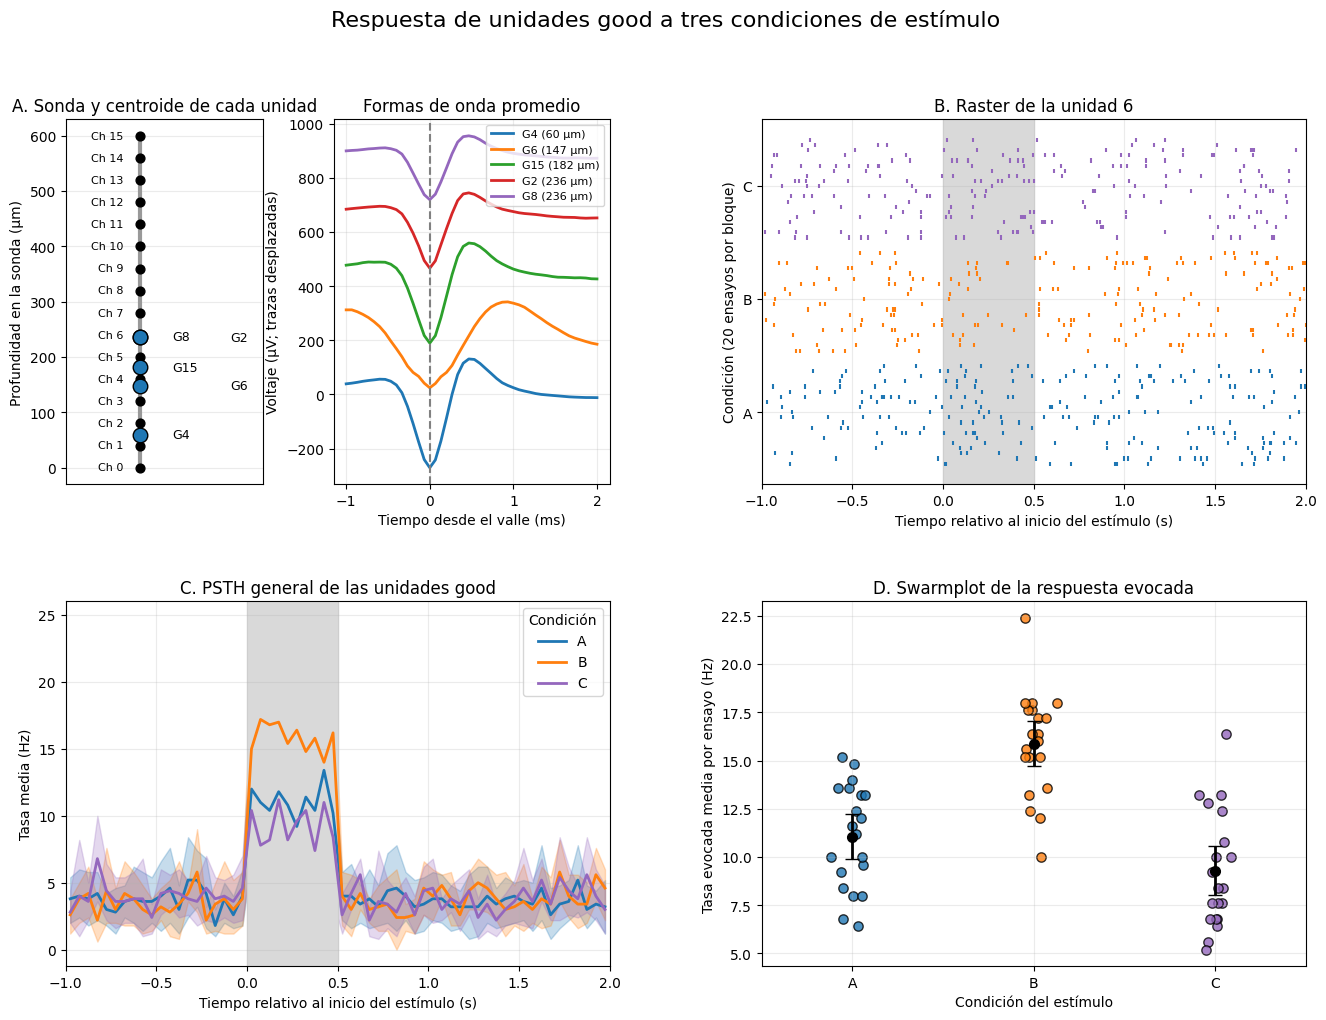

In [ ]:
fig = plt.figure(figsize=(16, 11))
gs = GridSpec(2, 2, figure=fig, wspace=0.28, hspace=0.32)

# =====================================================
# PANEL A
# =====================================================
gsA = gs[0, 0].subgridspec(
    1, 2,
    width_ratios=[1, 1.4],
    wspace=0.30
)

axA1 = fig.add_subplot(gsA[0, 0])
axA2 = fig.add_subplot(gsA[0, 1])

# ==========================================
# A1: sonda + centroides
# ==========================================

# Línea de la sonda
axA1.plot(
    np.zeros_like(y),
    y,
    color="0.6",
    linewidth=3
)

# Electrodos
axA1.scatter(
    np.zeros_like(y),
    y,
    s=40,
    color="black",
    zorder=3
)

# Nombres de los canales a la IZQUIERDA
for ch, yy in enumerate(y):
    axA1.text(
        -0.04,
        yy,
        f"Ch {ch}",
        va="center",
        ha="right",
        fontsize=8
    )

# Centroides de las unidades good
for j, item in enumerate(resumen_unidades):

    axA1.scatter(
        0.0,
        item["centroide_um"],
        s=110,
        color="tab:blue",
        edgecolor="black",
        zorder=4
    )

    # Alternar las etiquetas para que no se monten
    x_texto = 0.08 if j % 2 == 0 else 0.22

    axA1.text(
        x_texto,
        item["centroide_um"],
        f"G{item['grupo']}",
        va="center",
        fontsize=9
    )

axA1.set_xlim(-0.18, 0.30)
axA1.set_ylim(
    np.min(y) - 30,
    np.max(y) + 30
)

axA1.set_xticks([])
axA1.set_ylabel("Profundidad en la sonda (µm)")
axA1.set_title("A. Sonda y centroide de cada unidad")


# ==========================================
# A2: formas de onda promedio
# ==========================================

offset = 0

for item in resumen_unidades:
    onda = item["onda_rep"]

    axA2.plot(
        tiempo_ms,
        onda + offset,
        linewidth=2,
        label=f"G{item['grupo']} ({item['centroide_um']:.0f} µm)"
    )

    offset += 220

axA2.axvline(
    0,
    linestyle="--",
    color="0.5"
)

axA2.set_xlabel("Tiempo desde el valle (ms)")

# Cambié este texto para dejar claro que las ondas están desplazadas
axA2.set_ylabel("Voltaje (µV; trazas desplazadas)")

axA2.set_title("Formas de onda promedio")
axA2.legend(fontsize=8, loc="upper right")


# =====================================================
# PANEL B
# =====================================================
axB = fig.add_subplot(gs[0, 1])

tiempos_unidad = tiempos_v[grupos_curados == grupo_raster]
relativos = tiempos_relativos_por_ensayo(
    tiempos_unidad,
    inicios_ensayo,
    condiciones,
    pre_s=pre_s,
    duracion_estimulo_s=duracion_estimulo_s,
    post_s=post_s
)

y_inicio = 0
yticks = []
ylabels = []

for cond in condiciones_unicas:
    idx = np.where(np.array(condiciones) == cond)[0]
    ensayos_cond = [relativos[i] for i in idx]

    posiciones = np.arange(y_inicio, y_inicio + len(ensayos_cond))

    axB.eventplot(
        ensayos_cond,
        lineoffsets=posiciones,
        linelengths=0.8,
        colors=colores[cond]
    )

    yticks.append(y_inicio + len(ensayos_cond) / 2)
    ylabels.append(cond)

    y_inicio += len(ensayos_cond) + 2

axB.axvspan(0, duracion_estimulo_s, color="0.85")
axB.set_xlim(-pre_s, duracion_estimulo_s + post_s)
axB.set_yticks(yticks)
axB.set_yticklabels(ylabels)
axB.set_xlabel("Tiempo relativo al inicio del estímulo (s)")
axB.set_ylabel("Condición (20 ensayos por bloque)")
axB.set_title(f"B. Raster de la unidad {grupo_raster}")


# =====================================================
# PANEL C
# =====================================================
axC = fig.add_subplot(gs[1, 0])

for cond in condiciones_unicas:
    centros = psth_general[cond]["centros"]
    media = psth_general[cond]["media"]
    lo = psth_general[cond]["lo"]
    hi = psth_general[cond]["hi"]

    axC.plot(
        centros,
        media,
        color=colores[cond],
        linewidth=2,
        label=f"{cond}"
    )

    axC.fill_between(
        centros,
        lo,
        hi,
        color=colores[cond],
        alpha=0.25
    )

axC.axvspan(0, duracion_estimulo_s, color="0.85")
axC.set_xlim(-pre_s, duracion_estimulo_s + post_s)
axC.set_xlabel("Tiempo relativo al inicio del estímulo (s)")
axC.set_ylabel("Tasa media (Hz)")
axC.set_title("C. PSTH general de las unidades good")
axC.legend(title="Condición")


# =====================================================
# PANEL D
# =====================================================
axD = fig.add_subplot(gs[1, 1])

rng = np.random.default_rng(42)

for i, cond in enumerate(condiciones_unicas):
    vals = swarm_df.loc[
        swarm_df["condicion"] == cond,
        "tasa_estimulo_hz"
    ].to_numpy()

    x_jitter = rng.normal(i, 0.06, size=len(vals))

    axD.scatter(
        x_jitter,
        vals,
        color=colores[cond],
        alpha=0.8,
        edgecolor="black",
        s=45
    )

    media = np.mean(vals)
    lo, hi = bootstrap_media(vals, n_boot=5000, semilla=42)

    axD.errorbar(
        i,
        media,
        yerr=np.array([[media - lo], [hi - media]]),
        fmt="o",
        color="black",
        capsize=5,
        linewidth=2,
        markersize=7
    )

axD.axvspan(-0.5, 2.5, color="none")  # no hace nada visual, solo deja limpio
axD.set_xticks(range(len(condiciones_unicas)))
axD.set_xticklabels(condiciones_unicas)
axD.set_xlabel("Condición del estímulo")
axD.set_ylabel("Tasa evocada media por ensayo (Hz)")
axD.set_title("D. Swarmplot de la respuesta evocada")
axD.set_xlim(-0.5, 2.5)

plt.suptitle("Respuesta de unidades good a tres condiciones de estímulo", fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Elegimos la unidad 6 en la grafica B porque fue la que mostró una respuesta significativa a una sola condición. Su tasa de disparo aumentó durante el estímulo A, mientras que en B y C no hubo un cambio significativo, por lo que permite mostrar mejor el contraste entre condiciones en el raster.


**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva
- **c)** la latencia de la respuesta
- **d)** la tasa basal

**ANS -->** b

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*

Fig 1. Respuesta de cinco unidades neuronales aisladas ante tres condiciones de estímulo (A, B y C).

A. Demuestra la posición de la sonda en 16 canales y profundidad de los centroides de las cinco unidades (60 a 236 µm), y las formas de onda extracelulares promedio.

B. Es el raster de la unidad 6 para las condiciones A, B y C, con 20 ensayos por condición. La región sombreada indica el período de estimulación (0 a 0,5 s).

C. Histograma de tiempo peri-estímulo (PSTH) general, calculado promediando las tasas de disparo de las cinco unidades para cada condición. Las líneas representan las tasas medias de disparo (Hz) y las bandas sombreadas muestran la variabilidad de las respuestas.

D. Dispersión plot (swarmplot) de la tasa media de disparo durante el estímulo para las tres condiciones. Cada punto representa un ensayo y las barras negras muestran la media de cada condición con sus barras de error.


---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

**Resultados:**

El pipeline agrupó los eventos en 16 unidades candidatas y, después de fusionar los grupos 1 y 13, quedaron 15 grupos. Cinco fueron clasificados como good; los demás se descartaron como mua o noise por violaciones del período refractario, disparos faltantes, forma de onda o caída espacial. El grupo 14 fue clasificado como mua por presentar 27.3 % de violaciones refractarias y una razón pico/valle de 0.68, aunque la verificación posterior lo identificó como non-somatic. Esto probablemente ocurrió porque el grupo estaba contaminado, solo 40 % de sus eventos correspondían a U8, por lo que la mezcla pudo alterar la forma de onda promedio y reducir la razón pico/valle. La unidad 2 respondió a A (p=0.0046) y B (p=6.06×10⁻⁸), la 4 a A, B y C (p<10⁻⁶), la 6 solo a A (p=0.0081), la 8 a A (p=0.044) y B (p=3.61×10⁻⁷), y la 15 a las tres condiciones, con Z=9.79, 15.72 y 8.65 para A, B y C.

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

La IA propuso una función para etiquetar automáticamente los grupos a partir de los umbrales. Con esa versión, los grupos 2 y 15 quedaron como mua, y los grupos 10 y 12 como noise. Al correr verificar_curacion, solo 11 de 16 etiquetas coincidían con la verdad oculta.
Qué estaba mal: El problema no eran los umbrales, sino cómo la IA había calculado algunas métricas. La estimación de disparos faltantes estaba sobreestimando la fracción perdida, por lo que los grupos 2 y 15 parecían incompletos. Además, para la pendiente espacial se estaba tomando el mínimo de cada canal en momentos distintos, lo que aplanaba artificialmente el perfil de amplitud y hacía que los grupos 10 y 12 parecieran artefactos.
Cómo lo arreglamos: Corregimos el ajuste de disparos faltantes usando el pico del histograma como centro de la distribución y ajustando la mitad superior. Para la caída espacial, medimos la amplitud de los 16 canales en el mismo instante del valle del canal pico de cada evento. Después de estos cambios, 2 y 15 pasaron a good, 10 y 12 a mua, y la verificación mejoró de 11/16 a 15/16 grupos correctamente clasificados antes de considerar las fusiones.

**Intercambio 1**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**Intercambio 2**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**Intercambio 3**

*Prompt:*

*Respuesta del modelo:*

*Qué estaba mal:*

*Cómo lo corregimos:*

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas
- **d)** estandarizar las características antes de K-means

**ANS -->** C

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*
Sí estamos de acuerdo. Aunque el programa puede agrupar automáticamente los potenciales de acción, la identificación de neuronas individuales necesita  integrar diferentes criterios. Una decisión de automatizar incluyo determinar si los grupos 1 y 13 correspondían a la misma neurona. En cambio, automatizaríamos la detección de cruces del umbral y el cálculo de las violaciones del período refractario, ya que ambos pueden definirse mediante criterios numéricos.

---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [116]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "B",   "P2":  "B",   "P3":  "D",   "P4":  "D",
    "P5":  "C",   "P6":  "B",   "P7":  "D",   "P8":  "B",
    "P9":  "B",   "P10": "B",   "P11": "B",   "P12": "C",
}

numeros = {
    "eventos_limpia":        2705,   # sección 2
    "eventos_ruidosa":       18639,   # sección 4
    "k_elegido":             16,   # sección 4
    "grupos_good":           5,   # sección 7
    "grupos_mua":            9,   # sección 7
    "grupos_nonsomatic":     0,   # sección 7
    "grupos_noise":          1,   # sección 7
    "identificable_antes":   0.6543805998175868,   # sección 8
    "identificable_despues": 0.9585346215780999,   # sección 8
    "precision":             0.9886796501958259,   # sección 8
    "exhaustividad":         0.8865387410960895,   # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


selección múltiple
    P1  b
    P2  b
    P3  d
    P4  d
    P5  c
    P6  b
    P7  d
    P8  b
    P9  b
   P10  b
   P11  b
   P12  c

números del pipeline
          eventos_limpia  2705
         eventos_ruidosa  18639
               k_elegido  16
             grupos_good  5
              grupos_mua  9
       grupos_nonsomatic  0
            grupos_noise  1
     identificable_antes  0.6543805998175868
   identificable_despues  0.9585346215780999
               precision  0.9886796501958259
           exhaustividad  0.8865387410960895

sin llenar: ninguno


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.